In [52]:
import psycopg2
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Global Constants ──────────────────────────────────────────────
RANDOM_SEED = 42
TRAIN_SEASONS = [2022, 2023, 2024, 2025]
TEST_SIZE = 0.20
CONFERENCE_GAMES_ONLY = True
EXCLUDE_INDEPENDENTS = True

# ── DB Connection ─────────────────────────────────────────────────
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()

print("Connected.")
print(f"RANDOM_SEED={RANDOM_SEED} | TRAIN_SEASONS={TRAIN_SEASONS} | "
      f"TEST_SIZE={TEST_SIZE} | CONFERENCE_GAMES_ONLY={CONFERENCE_GAMES_ONLY} | "
      f"EXCLUDE_INDEPENDENTS={EXCLUDE_INDEPENDENTS}")

Connected.
RANDOM_SEED=42 | TRAIN_SEASONS=[2022, 2023, 2024, 2025] | TEST_SIZE=0.2 | CONFERENCE_GAMES_ONLY=True | EXCLUDE_INDEPENDENTS=True


In [53]:
query = """
SELECT
    g.id                    AS game_id,
    g.season,
    g.week,
    g.home_team,
    g.away_team,
    g.home_points,
    g.away_points,
    ht.conference           AS home_conference,
    at.conference           AS away_conference,
    g.neutral_site          AS is_neutral,
    e.is_dome
FROM raw.games g
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
JOIN int.int_team_season_features at
    ON at.team_name = g.away_team AND at.season = g.season
LEFT JOIN int.int_game_environment e
    ON e.game_id = g.id
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND ht.conference != 'FBS Independents'
  AND at.conference != 'FBS Independents'
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
"""

cur.execute(query)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = ['home_points', 'away_points']
df[numeric_cols] = df[numeric_cols].astype(float)

df['point_differential'] = df['home_points'] - df['away_points']
df['total_points'] = df['home_points'] + df['away_points']

for col in ['is_neutral', 'is_dome']:
    df[col] = df[col].map(lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

# ── FBS Integrity Assert ──────────────────────────────────────────
assert 'FBS Independents' not in df['home_conference'].values, \
    "FBS Independent found in home_conference"
assert 'FBS Independents' not in df['away_conference'].values, \
    "FBS Independent found in away_conference"
assert df['season'].isin(TRAIN_SEASONS).all(), \
    "Season out of range found after filter"

print(f"Rows: {len(df)}")
print(f"Games per season:\n{df.groupby('season').size()}")
print(f"\nMissing values:\n{df[['point_differential','total_points','is_dome','is_neutral']].isnull().sum()}")
print(f"\npoint_differential — mean: {df['point_differential'].mean():.2f}, std: {df['point_differential'].std():.2f}")
print(f"total_points       — mean: {df['total_points'].mean():.2f}, std: {df['total_points'].std():.2f}")

Rows: 2155
Games per season:
season
2022    523
2023    546
2024    538
2025    548
dtype: int64

Missing values:
point_differential    0
total_points          0
is_dome               0
is_neutral            0
dtype: int64

point_differential — mean: 2.45, std: 18.92
total_points       — mean: 53.63, std: 17.00


In [54]:
conferences = sorted(df['home_conference'].unique())

conf_season_stats = []
for conference in conferences:
    for season in [2022, 2023, 2024, 2025]:
        s = df[(df['home_conference'] == conference) & (df['season'] == season)]
        if len(s) == 0:
            continue
        conf_season_stats.append({
            'conference': conference,
            'season': season,
            'n': len(s),
            'pd_mean': round(s['point_differential'].mean(), 2),
            'pd_std': round(s['point_differential'].std(), 2),
            'pd_skew': round(stats.skew(s['point_differential'].values), 3),
            'tp_mean': round(s['total_points'].mean(), 2),
            'tp_std': round(s['total_points'].std(), 2),
            'tp_skew': round(stats.skew(s['total_points'].values), 3),
        })

conf_season_df = pd.DataFrame(conf_season_stats)
print("Conference × Season Summary Statistics")
print(conf_season_df.to_string(index=False))

Conference × Season Summary Statistics
       conference  season  n  pd_mean  pd_std  pd_skew  tp_mean  tp_std  tp_skew
              ACC    2022 56     0.66   17.74   -0.337    51.20   14.42    0.476
              ACC    2023 57     3.72   16.69   -0.297    51.40   16.13    0.199
              ACC    2024 69     2.48   15.40   -0.078    55.87   15.35    0.515
              ACC    2025 68     2.04   17.96    0.055    52.72   14.60    0.637
American Athletic    2022 45     2.38   17.46    0.525    61.89   21.94    0.837
American Athletic    2023 57     1.21   20.52    0.044    57.14   19.73   -0.109
American Athletic    2024 58     3.29   23.53   -0.342    60.12   19.43   -0.003
American Athletic    2025 57     2.39   22.73    0.031    59.16   16.87   -0.013
           Big 12    2022 46     2.48   19.07   -0.058    60.09   19.14   -0.185
           Big 12    2023 64     5.92   19.73    0.182    58.11   15.30    0.587
           Big 12    2024 73     3.15   18.00    0.243    55.70   16.3

In [55]:
print("KS Tests — each season vs every other season, within conference")
print(f"\n{'Conference':<22} {'S1':<6} {'S2':<6} {'PD D':>8} {'PD p':>8} {'TP D':>8} {'TP p':>8}")

season_pairs = [(2022,2023),(2022,2024),(2022,2025),(2023,2024),(2023,2025),(2024,2025)]

for conference in conferences:
    conf_data = df[df['home_conference'] == conference]
    printed_conf = False
    for s1, s2 in season_pairs:
        d1 = conf_data[conf_data['season'] == s1]
        d2 = conf_data[conf_data['season'] == s2]
        if len(d1) < 5 or len(d2) < 5:
            continue
        D_pd, p_pd = stats.ks_2samp(d1['point_differential'].values,
                                     d2['point_differential'].values)
        D_tp, p_tp = stats.ks_2samp(d1['total_points'].values,
                                     d2['total_points'].values)
        conf_label = conference if not printed_conf else ''
        print(f"{conf_label:<22} {s1:<6} {s2:<6} {D_pd:>8.4f} {p_pd:>8.4f} {D_tp:>8.4f} {p_tp:>8.4f}")
        printed_conf = True

KS Tests — each season vs every other season, within conference

Conference             S1     S2         PD D     PD p     TP D     TP p
ACC                    2022   2023     0.2033   0.1626   0.0865   0.9618
                       2022   2024     0.0916   0.9284   0.1545   0.3992
                       2022   2025     0.0882   0.9478   0.1008   0.8735
                       2023   2024     0.1259   0.6483   0.1495   0.4354
                       2023   2025     0.1610   0.3482   0.1138   0.7597
                       2024   2025     0.1049   0.7987   0.1535   0.3453
American Athletic      2022   2023     0.1135   0.8568   0.1404   0.6410
                       2022   2024     0.1544   0.5167   0.1119   0.8628
                       2022   2025     0.1661   0.4345   0.1076   0.8949
                       2023   2024     0.1485   0.4839   0.1183   0.7437
                       2023   2025     0.1053   0.9141   0.1053   0.9141
                       2024   2025     0.0796   0.9812   0.

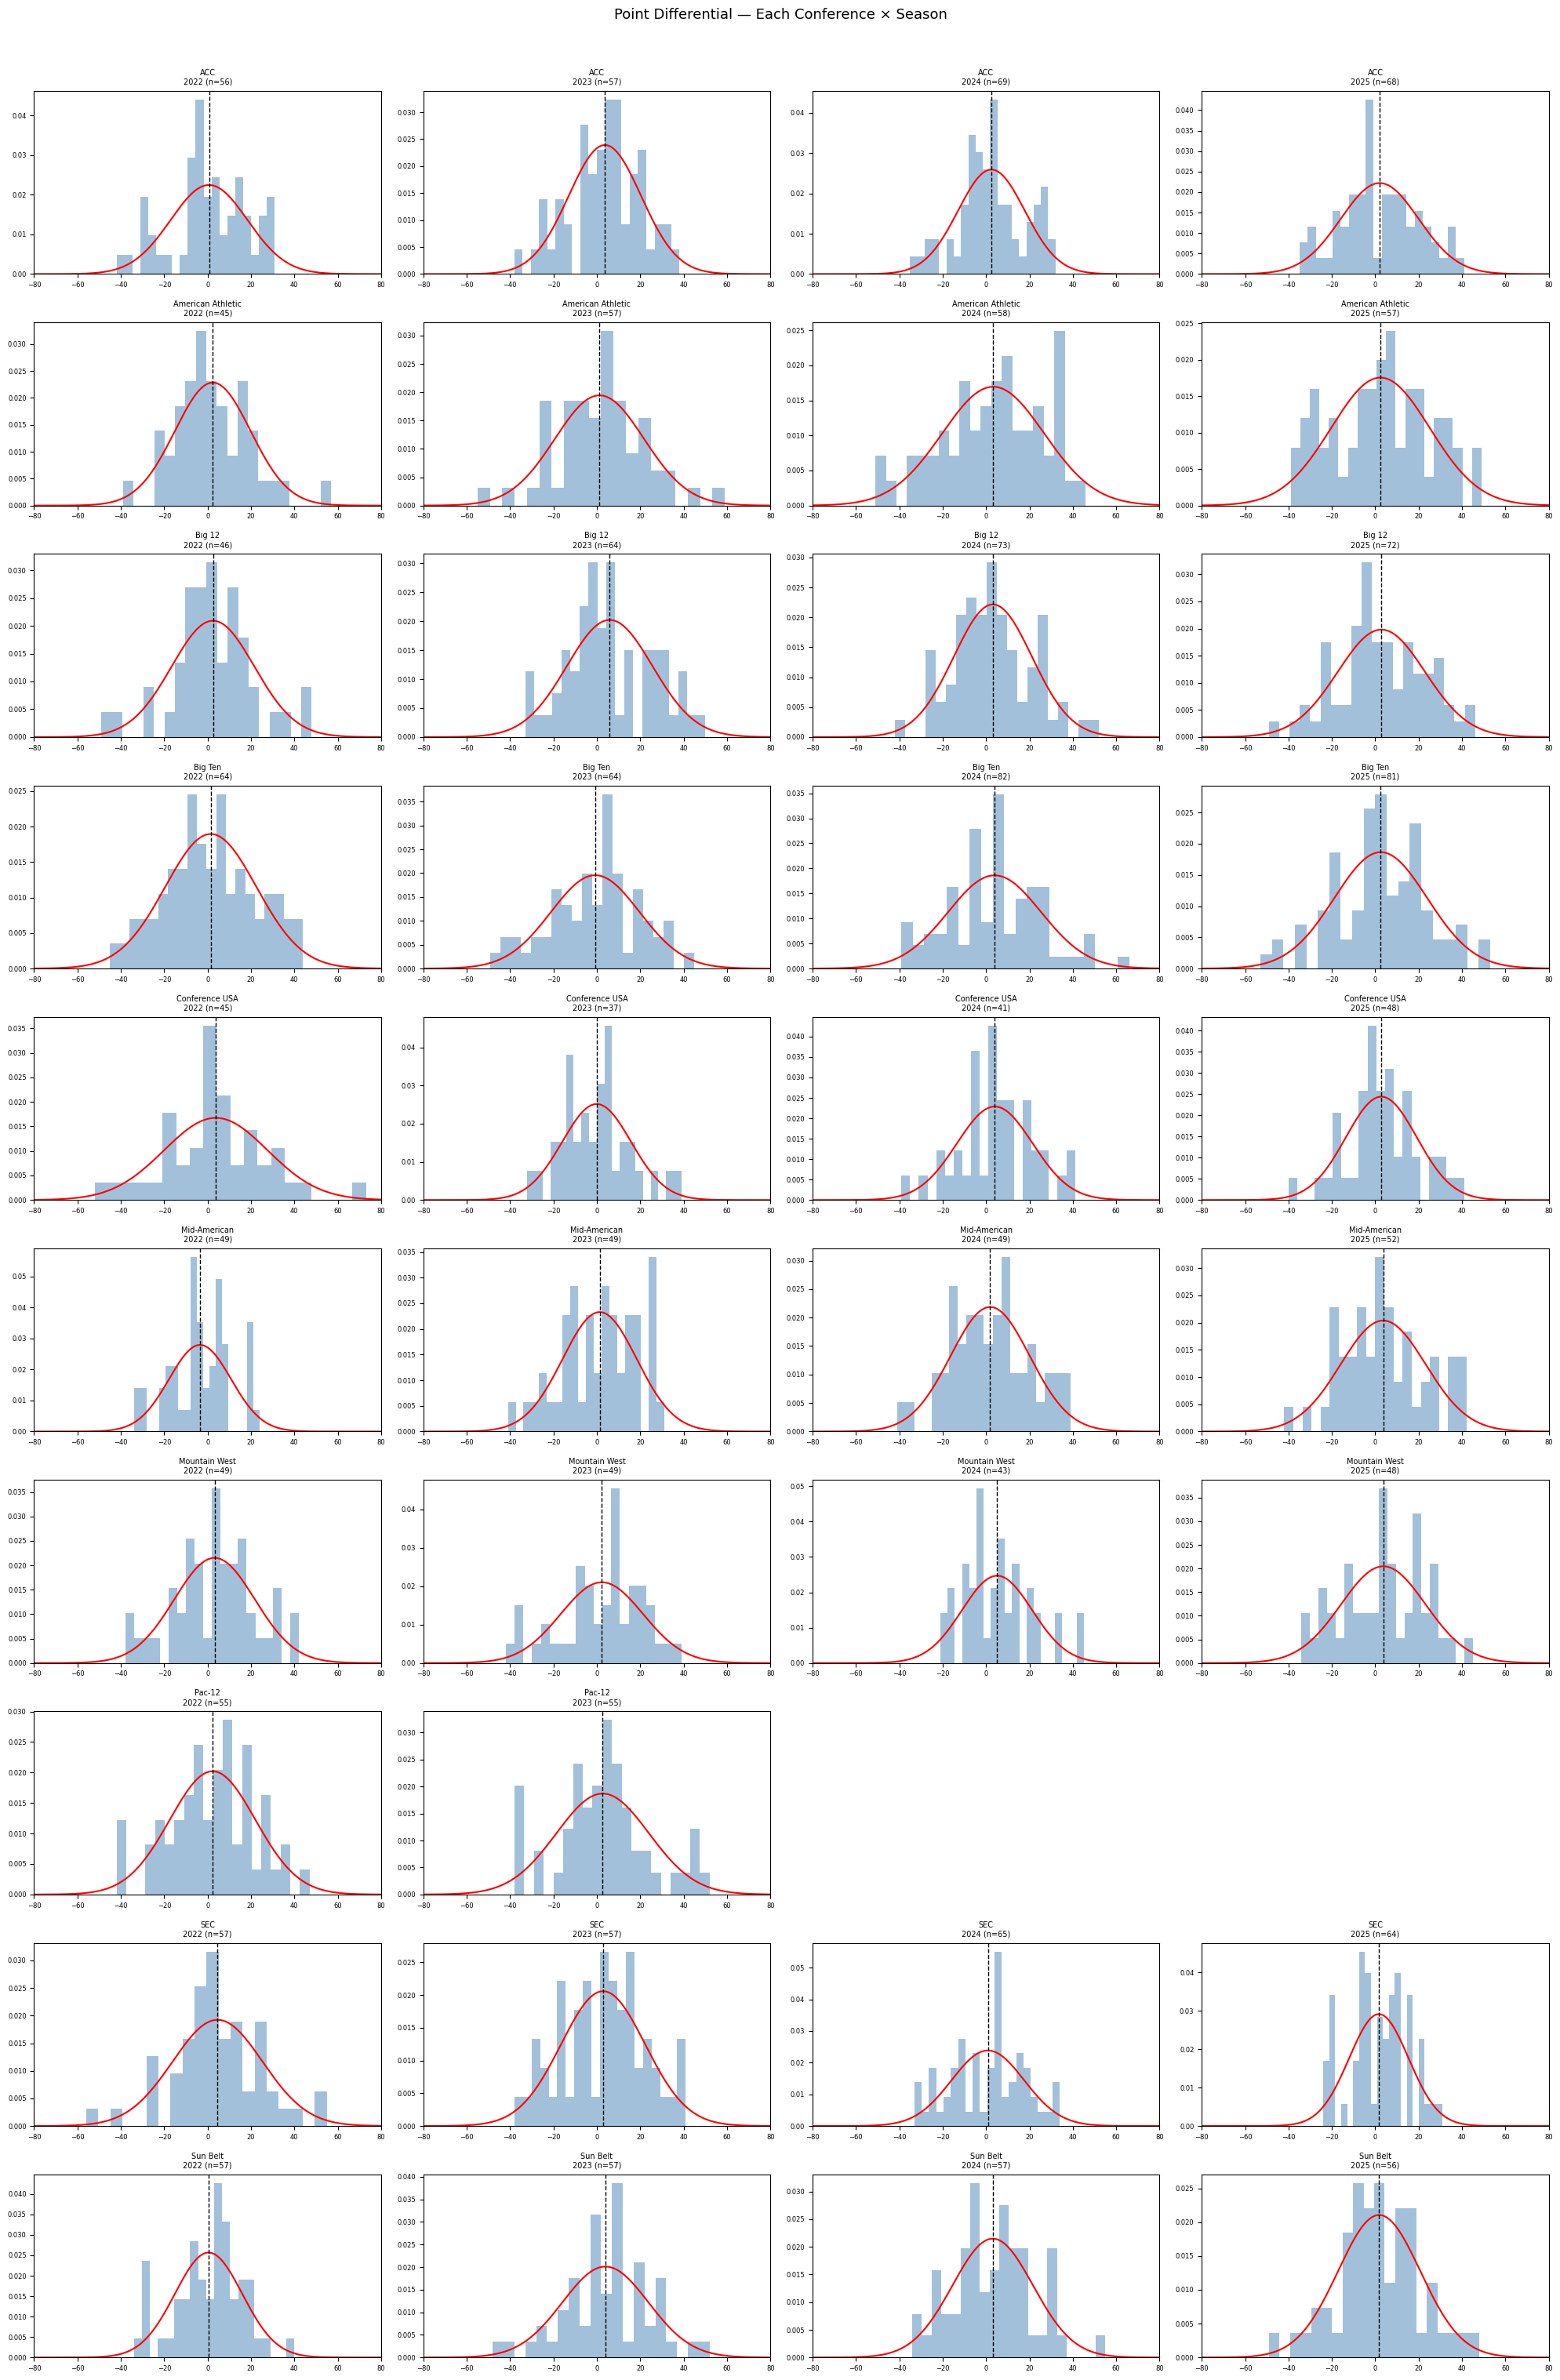

In [56]:
n_confs = len(conferences)
fig, axes = plt.subplots(n_confs, 4, figsize=(20, n_confs * 3))

for i, conference in enumerate(conferences):
    for j, season in enumerate([2022, 2023, 2024, 2025]):
        ax = axes[i, j]
        s = df[(df['home_conference'] == conference) & (df['season'] == season)]
        if len(s) < 3:
            ax.set_visible(False)
            continue
        ax.hist(s['point_differential'].values, bins=20, density=True,
                alpha=0.5, color='steelblue')
        mu, std = s['point_differential'].mean(), s['point_differential'].std()
        x = np.linspace(-80, 80, 300)
        ax.plot(x, stats.norm.pdf(x, mu, std), color='red', lw=1.5)
        ax.axvline(mu, color='black', linestyle='--', lw=1)
        ax.set_title(f'{conference}\n{season} (n={len(s)})', fontsize=7)
        ax.set_xlim(-80, 80)
        ax.tick_params(labelsize=6)

plt.suptitle('Point Differential — Each Conference × Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

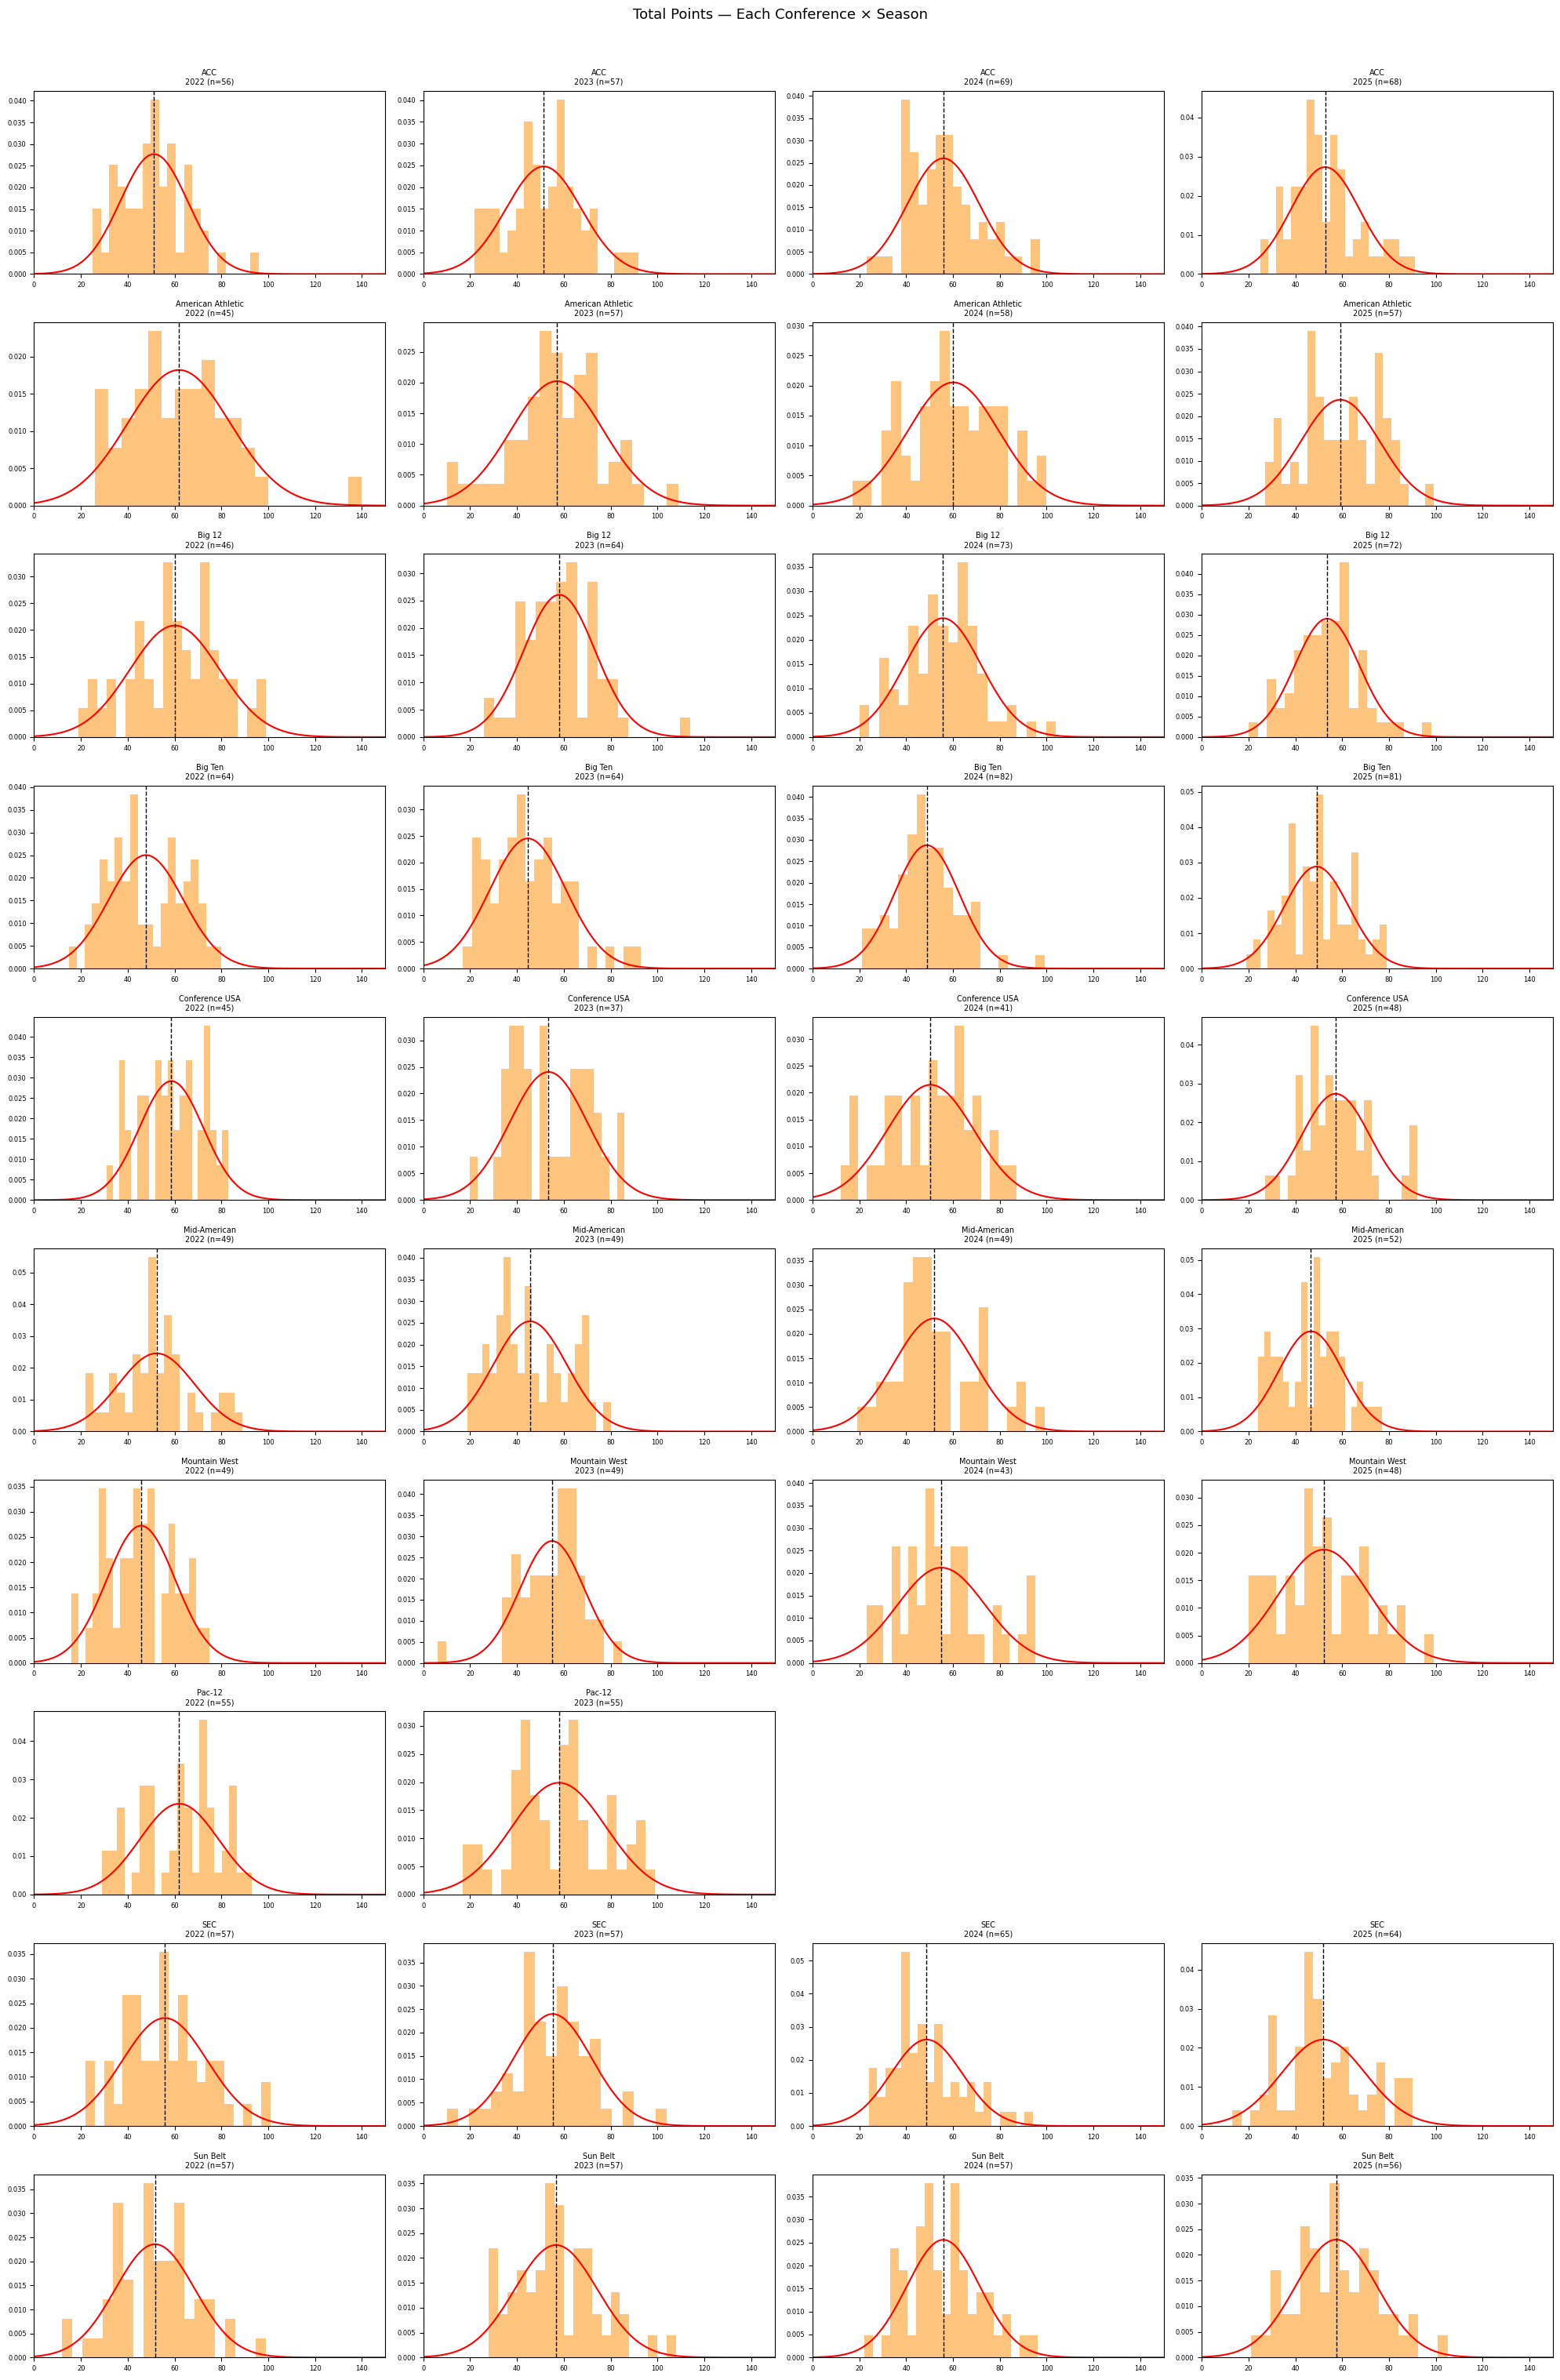

In [57]:
fig, axes = plt.subplots(n_confs, 4, figsize=(20, n_confs * 3))

for i, conference in enumerate(conferences):
    for j, season in enumerate([2022, 2023, 2024, 2025]):
        ax = axes[i, j]
        s = df[(df['home_conference'] == conference) & (df['season'] == season)]
        if len(s) < 3:
            ax.set_visible(False)
            continue
        ax.hist(s['total_points'].values, bins=20, density=True,
                alpha=0.5, color='darkorange')
        mu, std = s['total_points'].mean(), s['total_points'].std()
        x = np.linspace(0, 150, 300)
        ax.plot(x, stats.norm.pdf(x, mu, std), color='red', lw=1.5)
        ax.axvline(mu, color='black', linestyle='--', lw=1)
        ax.set_title(f'{conference}\n{season} (n={len(s)})', fontsize=7)
        ax.set_xlim(0, 150)
        ax.tick_params(labelsize=6)

plt.suptitle('Total Points — Each Conference × Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [58]:
sec = df[df['home_conference'] == 'SEC'].copy()

# ── Season summaries ──────────────────────────────────────────────
print("SEC — Season Summary")
print(f"{'Season':<8} {'n':>4} {'TP Mean':>8} {'TP Std':>8} {'TP Skew':>8} {'PD Mean':>8} {'PD Std':>8}")
for season in [2022, 2023, 2024, 2025]:
    s = sec[sec['season'] == season]
    print(f"{season:<8} {len(s):>4} {s['total_points'].mean():>8.2f} "
          f"{s['total_points'].std():>8.2f} "
          f"{stats.skew(s['total_points'].values):>8.3f} "
          f"{s['point_differential'].mean():>8.2f} "
          f"{s['point_differential'].std():>8.2f}")

# ── Which teams appear in SEC by season ──────────────────────────
print("\nSEC Teams by Season:")
for season in [2022, 2023, 2024, 2025]:
    s = sec[sec['season'] == season]
    teams = sorted(set(s['home_team'].tolist() + s['away_team'].tolist()))
    print(f"\n{season} (n={len(s)}):")
    print(', '.join(teams))

# ── New entrants 2024 — Texas and Oklahoma games specifically ─────
print("\n\nTexas and Oklahoma 2024-2025 games in SEC:")
new_teams = sec[
    (sec['season'].isin([2024, 2025])) &
    ((sec['home_team'].isin(['Texas', 'Oklahoma'])) |
     (sec['away_team'].isin(['Texas', 'Oklahoma'])))
][['season', 'week', 'home_team', 'away_team', 'home_points', 
   'away_points', 'total_points', 'point_differential']]
print(new_teams.sort_values(['season', 'week']).to_string(index=False))

# ── SEC total points distribution with and without Texas/Oklahoma ─
print("\n\nSEC 2024 Total Points — with vs without Texas/Oklahoma:")
sec_2024 = sec[sec['season'] == 2024]
with_new = sec_2024[
    (sec_2024['home_team'].isin(['Texas', 'Oklahoma'])) |
    (sec_2024['away_team'].isin(['Texas', 'Oklahoma']))
]
without_new = sec_2024[
    ~(sec_2024['home_team'].isin(['Texas', 'Oklahoma'])) &
    ~(sec_2024['away_team'].isin(['Texas', 'Oklahoma']))
]
print(f"Games involving Texas or Oklahoma: n={len(with_new)}, "
      f"tp_mean={with_new['total_points'].mean():.2f}, "
      f"tp_std={with_new['total_points'].std():.2f}")
print(f"Games without Texas or Oklahoma:   n={len(without_new)}, "
      f"tp_mean={without_new['total_points'].mean():.2f}, "
      f"tp_std={without_new['total_points'].std():.2f}")

# ── Week-by-week total points within SEC by season ───────────────
print("\n\nSEC Total Points by Week and Season:")
sec_weekly = sec.groupby(['season', 'week'])['total_points'].agg(['mean', 'count']).reset_index()
sec_weekly.columns = ['season', 'week', 'tp_mean', 'n']
for season in [2022, 2023, 2024, 2025]:
    sw = sec_weekly[sec_weekly['season'] == season]
    print(f"\n{season}:")
    print(sw.to_string(index=False))

SEC — Season Summary
Season      n  TP Mean   TP Std  TP Skew  PD Mean   PD Std
2022       57    55.84    18.14    0.366     4.58    20.74
2023       57    55.25    16.65    0.132     2.89    19.38
2024       65    48.74    15.26    0.774     0.83    16.72
2025       64    51.97    18.04    0.327     1.66    13.68

SEC Teams by Season:

2022 (n=57):
Alabama, Arkansas, Auburn, Florida, Georgia, Kentucky, LSU, Mississippi State, Missouri, Ole Miss, South Carolina, Tennessee, Texas A&M, Vanderbilt

2023 (n=57):
Alabama, Arkansas, Auburn, Florida, Georgia, Kentucky, LSU, Mississippi State, Missouri, Ole Miss, South Carolina, Tennessee, Texas A&M, Vanderbilt

2024 (n=65):
Alabama, Arkansas, Auburn, Florida, Georgia, Kentucky, LSU, Mississippi State, Missouri, Oklahoma, Ole Miss, South Carolina, Tennessee, Texas, Texas A&M, Vanderbilt

2025 (n=64):
Alabama, Arkansas, Auburn, Florida, Georgia, Kentucky, LSU, Mississippi State, Missouri, Oklahoma, Ole Miss, South Carolina, Tennessee, Texas, Te

## EDA 1 — Conference × Season Distribution Analysis

**Date:** May 17, 2026
**Analyst:** CFB Model Rebuild

---

### What We Did

Computed point differential and total points summary statistics (mean, std, skew)
for every conference × season combination in the training pool. Ran pairwise KS tests
for every season combination within each conference — season by season, not pooled —
to identify where the data generating process shifted meaningfully across years.
Followed up with a deep dive on the SEC to understand whether its 2024 scoring drop
was structural or explainable.

---

### Decisions and Justifications

**American Athletic 2022 — DROPPED**
SMU and Houston were members of the American Athletic in 2022. Both left after 2023
(SMU to the ACC, Houston to the Big 12). The 2022 American Athletic had a total points
mean of 61.89 with std of 21.94 and tp_skew of 0.837 — the highest skew of any
conference × season in the dataset. After both programs departed, total points dropped
to the 57-60 range with near-zero skew. The 2022 American Athletic is a structurally
different scoring environment from every subsequent season and does not represent
the current conference.

**Mountain West 2022 — DROPPED**
KS tests showed statistically significant total points shifts between 2022 and 2023
(D=0.327, p=0.010) and between 2022 and 2024 (D=0.281, p=0.042). The Mountain West
in 2022 averaged 45.65 total points per game — more than 9 points lower than every
subsequent season. This is a structural shift, not random variation. 2023-2025 are
stable and retained.

**Big 12 2022 — DROPPED**
The Big 12 underwent significant expansion between 2022 and 2025, absorbing programs
from the collapsed Pac-12 and other conferences. Total points declined from 60.09 in
2022 to 53.54 in 2025. KS test for total points 2022 vs 2025: D=0.276, p=0.0216 —
the only statistically significant cross-season shift of this magnitude in the dataset.
The Big 12 of 2022 is a materially different conference from the Big 12 of 2025 in
both composition and scoring environment.

**Pac-12 — ALL SEASONS DROPPED**
The Pac-12 collapsed after the 2023 season. 2024 produced 1 usable game and 2025
produced 2 — neither are sufficient for inference. More importantly, the programs
that comprised the Pac-12 dispersed across the ACC, Big Ten, and Big 12. Their
historical Pac-12 game outcomes do not inform predictions about their current
conference play — the opponents, scoring environments, and competitive contexts
are entirely different. Oregon's 2023 Pac-12 season is not a useful prior for
Oregon's 2024-2025 Big Ten performance. All Pac-12 seasons dropped.

**SEC — ALL SEASONS RETAINED**
The KS test between 2023 and 2024 total points was significant (D=0.284, p=0.012),
and the 2024 SEC total points mean dropped to 48.74 from 55+ in prior seasons.
Deep dive analysis showed this was driven primarily by Oklahoma's historically poor
transition year in 2024 (6-7, first SEC season), not a structural change in how the
SEC plays football. Oklahoma games in 2024 averaged 43.31 total points versus 50.51
for the rest of the conference. By 2025 the SEC mean recovered to 51.97, consistent
with 2022-2023 levels. The 2024 scoring drop is a team-quality artifact, not a
conference structural shift. All SEC seasons retained.

**ACC, Big Ten, Conference USA, Mid-American, Sun Belt — ALL SEASONS RETAINED**
No statistically significant distributional shifts were found across any season pair
for these conferences on either point differential or total points. All seasons
are drawn from a stable process and are retained in full.

---

### Implications for the Training Pool

The following data is excluded from all subsequent analysis and model training:

| Conference | Seasons Dropped |
|---|---|
| American Athletic | 2022 |
| Mountain West | 2022 |
| Big 12 | 2022 |
| Pac-12 | 2022, 2023, 2024, 2025 |

All other conference × season combinations are retained.

These decisions are locked. They do not get reopened in subsequent sessions
without explicit direction and new empirical evidence.

---

### What This Means for Recency Weighting

The rebuild plan assumed uniform recency discounting of 2022. The data does not
support a uniform approach. The decision to drop or retain 2022 is conference-specific,
driven by whether the 2022 data for that conference represents the same process
as 2024-2025. Conferences where 2022 is structurally comparable to recent seasons
retain it. Conferences where it is not have it dropped entirely. Partial weighting
of 2022 data is not applied — a season is either in or out for a given conference.

In [59]:
query = """
SELECT
    g.id                    AS game_id,
    g.season,
    g.week,
    g.home_team,
    g.away_team,
    g.home_points,
    g.away_points,
    ht.conference           AS home_conference,
    at.conference           AS away_conference,
    g.neutral_site          AS is_neutral,
    e.is_dome
FROM raw.games g
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
JOIN int.int_team_season_features at
    ON at.team_name = g.away_team AND at.season = g.season
LEFT JOIN int.int_game_environment e
    ON e.game_id = g.id
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND ht.conference != 'FBS Independents'
  AND at.conference != 'FBS Independents'
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
  AND NOT (ht.conference = 'American Athletic'  AND g.season = 2022)
  AND NOT (ht.conference = 'Mountain West'      AND g.season = 2022)
  AND NOT (ht.conference = 'Big 12'             AND g.season = 2022)
  AND NOT (ht.conference = 'Pac-12')
"""

cur.execute(query)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = ['home_points', 'away_points']
df[numeric_cols] = df[numeric_cols].astype(float)

df['point_differential'] = df['home_points'] - df['away_points']
df['total_points'] = df['home_points'] + df['away_points']

for col in ['is_neutral', 'is_dome']:
    df[col] = df[col].map(lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

# ── FBS Integrity Assert ──────────────────────────────────────────
assert 'FBS Independents' not in df['home_conference'].values, \
    "FBS Independent found in home_conference"
assert 'FBS Independents' not in df['away_conference'].values, \
    "FBS Independent found in away_conference"
assert df['season'].isin(TRAIN_SEASONS).all(), \
    "Season out of range found after filter"
assert 'Pac-12' not in df['home_conference'].values, \
    "Pac-12 found after filter"
assert not ((df['home_conference'] == 'American Athletic') & (df['season'] == 2022)).any(), \
    "American Athletic 2022 found after filter"
assert not ((df['home_conference'] == 'Mountain West') & (df['season'] == 2022)).any(), \
    "Mountain West 2022 found after filter"
assert not ((df['home_conference'] == 'Big 12') & (df['season'] == 2022)).any(), \
    "Big 12 2022 found after filter"

print(f"Rows: {len(df)}")
print(f"\nGames per season:\n{df.groupby('season').size()}")
print(f"\nGames per conference × season:")
print(df.groupby(['home_conference', 'season']).size().unstack(fill_value=0).to_string())
print(f"\nMissing values:\n{df[['point_differential','total_points','is_dome','is_neutral']].isnull().sum()}")
print(f"\npoint_differential — mean: {df['point_differential'].mean():.2f}, std: {df['point_differential'].std():.2f}")
print(f"total_points       — mean: {df['total_points'].mean():.2f}, std: {df['total_points'].std():.2f}")

Rows: 1902

Games per season:
season
2022    328
2023    491
2024    537
2025    546
dtype: int64

Games per conference × season:
season             2022  2023  2024  2025
home_conference                          
ACC                  56    57    69    68
American Athletic     0    57    58    57
Big 12                0    64    73    72
Big Ten              64    64    82    81
Conference USA       45    37    41    48
Mid-American         49    49    49    52
Mountain West         0    49    43    48
SEC                  57    57    65    64
Sun Belt             57    57    57    56

Missing values:
point_differential    0
total_points          0
is_dome               0
is_neutral            0
dtype: int64

point_differential — mean: 2.42, std: 18.90
total_points       — mean: 53.13, std: 16.57


Overall — Point Differential and Total Points by Week (Week 5+)

Week      n  PD Mean   PD Std  TP Mean   TP Std
5       151     2.82    17.05    54.03    16.20
6       159     2.16    19.48    53.37    16.08
7       178     2.54    18.32    53.71    17.13
8       188     1.99    17.89    50.77    17.50
9       174     5.03    18.59    53.61    15.76
10      179    -0.17    18.35    53.54    17.62
11      188     4.39    20.45    51.90    15.66
12      181     4.90    18.50    51.36    16.76
13      197     0.93    19.28    55.39    16.85
14      134     0.75    21.20    53.71    16.09
15        9     4.44    24.56    52.00    17.71
16        2    -8.50    13.44    38.50     7.78


Overall — By Month

Month           n  PD Mean   PD Std  TP Mean   TP Std
October       676     2.36    18.17    52.88    16.80
November      919     2.98    19.15    53.19    16.57
December      145     0.86    21.26    53.39    16.13


By Conference and Month (Week 5+)

Conference             Month        

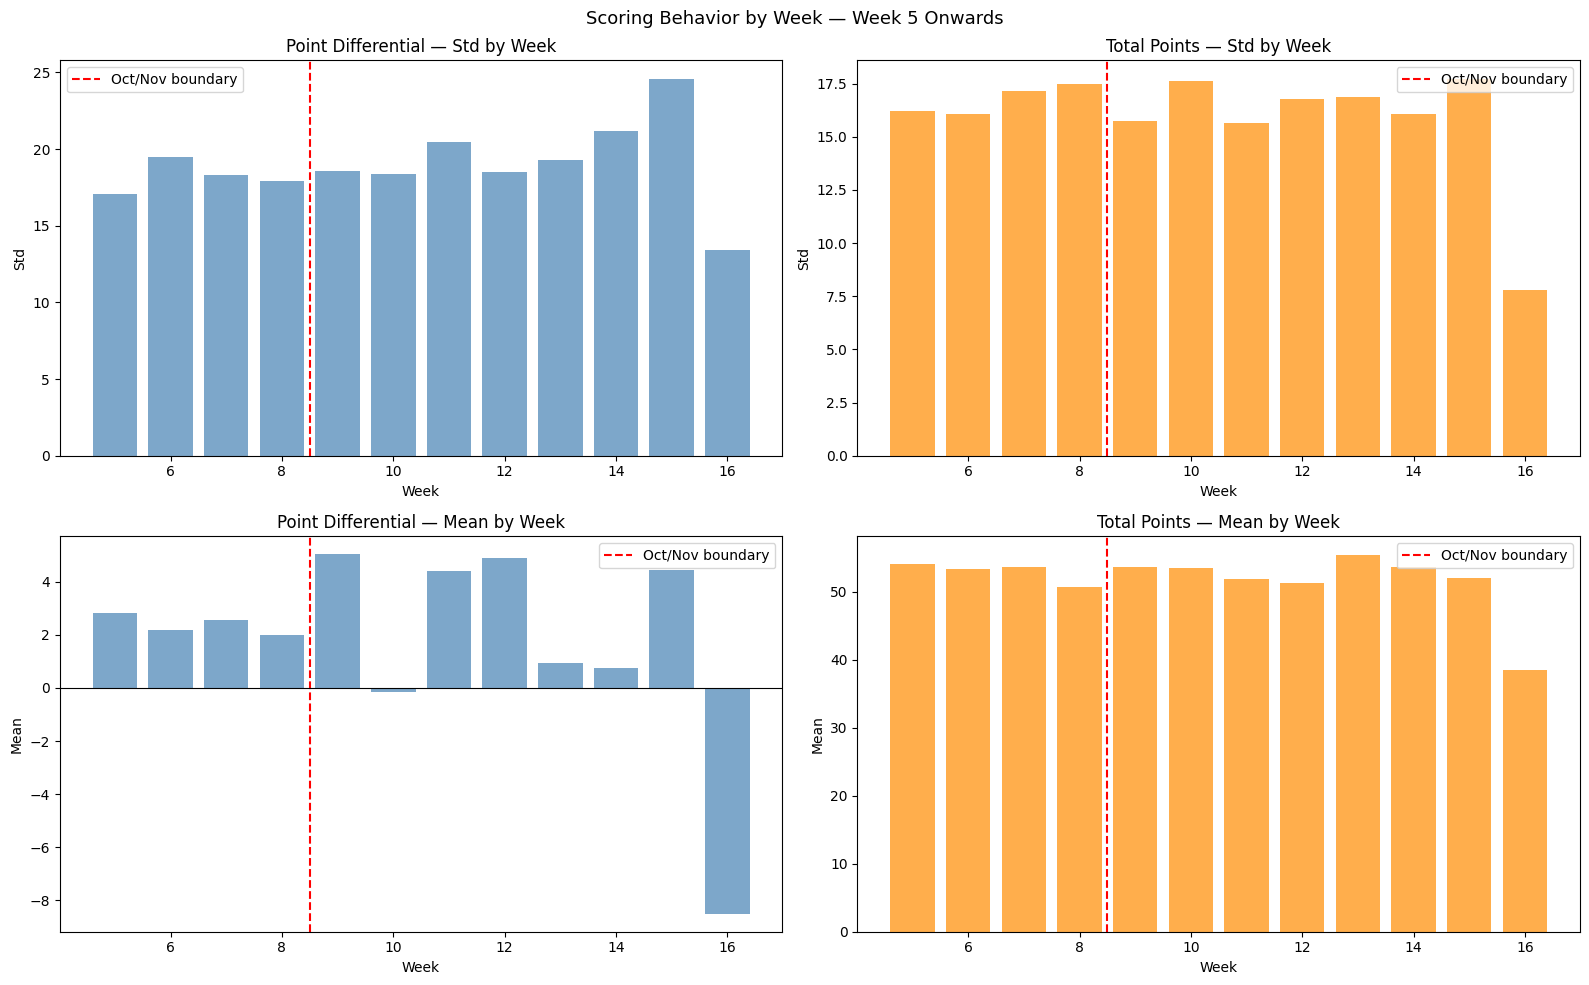

In [60]:
# Filter to Week 5 onwards — model prediction window
df_w5 = df[df['week'] >= 5].copy()

# Approximate month from week — CFB weeks map roughly as:
# Weeks 1-4: September, Weeks 5-8: October, Weeks 9-13: November, Week 14+: December
def week_to_month(week):
    if week <= 4:
        return 'September'
    elif week <= 8:
        return 'October'
    elif week <= 13:
        return 'November'
    else:
        return 'December'

df_w5['month'] = df_w5['week'].apply(week_to_month)

# ── Overall: variance and mean by week ───────────────────────────
print("Overall — Point Differential and Total Points by Week (Week 5+)")
print(f"\n{'Week':<6} {'n':>4} {'PD Mean':>8} {'PD Std':>8} {'TP Mean':>8} {'TP Std':>8}")
for week in sorted(df_w5['week'].unique()):
    w = df_w5[df_w5['week'] == week]
    print(f"{week:<6} {len(w):>4} {w['point_differential'].mean():>8.2f} "
          f"{w['point_differential'].std():>8.2f} "
          f"{w['total_points'].mean():>8.2f} "
          f"{w['total_points'].std():>8.2f}")

# ── By month ─────────────────────────────────────────────────────
print("\n\nOverall — By Month")
print(f"\n{'Month':<12} {'n':>4} {'PD Mean':>8} {'PD Std':>8} {'TP Mean':>8} {'TP Std':>8}")
for month in ['October', 'November', 'December']:
    m = df_w5[df_w5['month'] == month]
    if len(m) == 0:
        continue
    print(f"{month:<12} {len(m):>4} {m['point_differential'].mean():>8.2f} "
          f"{m['point_differential'].std():>8.2f} "
          f"{m['total_points'].mean():>8.2f} "
          f"{m['total_points'].std():>8.2f}")

# ── By conference and month ───────────────────────────────────────
print("\n\nBy Conference and Month (Week 5+)")
print(f"\n{'Conference':<22} {'Month':<12} {'n':>4} {'PD Mean':>8} {'PD Std':>8} {'TP Mean':>8} {'TP Std':>8}")
for conference in sorted(df_w5['home_conference'].unique()):
    for month in ['October', 'November', 'December']:
        m = df_w5[(df_w5['home_conference'] == conference) & 
                  (df_w5['month'] == month)]
        if len(m) < 5:
            continue
        print(f"{conference:<22} {month:<12} {len(m):>4} "
              f"{m['point_differential'].mean():>8.2f} "
              f"{m['point_differential'].std():>8.2f} "
              f"{m['total_points'].mean():>8.2f} "
              f"{m['total_points'].std():>8.2f}")

# ── Plot: std by week for both targets ───────────────────────────
weekly_stats = df_w5.groupby('week').agg(
    pd_std=('point_differential', 'std'),
    tp_std=('total_points', 'std'),
    pd_mean=('point_differential', 'mean'),
    tp_mean=('total_points', 'mean'),
    n=('game_id', 'count')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Point differential std by week
ax = axes[0, 0]
ax.bar(weekly_stats['week'], weekly_stats['pd_std'], color='steelblue', alpha=0.7)
ax.axvline(8.5, color='red', linestyle='--', lw=1.5, label='Oct/Nov boundary')
ax.set_title('Point Differential — Std by Week')
ax.set_xlabel('Week')
ax.set_ylabel('Std')
ax.legend()

# Total points std by week
ax = axes[0, 1]
ax.bar(weekly_stats['week'], weekly_stats['tp_std'], color='darkorange', alpha=0.7)
ax.axvline(8.5, color='red', linestyle='--', lw=1.5, label='Oct/Nov boundary')
ax.set_title('Total Points — Std by Week')
ax.set_xlabel('Week')
ax.set_ylabel('Std')
ax.legend()

# Point differential mean by week
ax = axes[1, 0]
ax.bar(weekly_stats['week'], weekly_stats['pd_mean'], color='steelblue', alpha=0.7)
ax.axvline(8.5, color='red', linestyle='--', lw=1.5, label='Oct/Nov boundary')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Point Differential — Mean by Week')
ax.set_xlabel('Week')
ax.set_ylabel('Mean')
ax.legend()

# Total points mean by week
ax = axes[1, 1]
ax.bar(weekly_stats['week'], weekly_stats['tp_mean'], color='darkorange', alpha=0.7)
ax.axvline(8.5, color='red', linestyle='--', lw=1.5, label='Oct/Nov boundary')
ax.set_title('Total Points — Mean by Week')
ax.set_xlabel('Week')
ax.set_ylabel('Mean')
ax.legend()

plt.suptitle('Scoring Behavior by Week — Week 5 Onwards', fontsize=13)
plt.tight_layout()
plt.show()

In [61]:
mw = df[(df['home_conference'] == 'Mountain West') & (df['week'] >= 5)].copy()
mw['month'] = mw['week'].apply(week_to_month)

# ── Summary by month ──────────────────────────────────────────────
print("Mountain West — October vs November Summary")
print(f"\n{'Month':<12} {'n':>4} {'TP Mean':>8} {'TP Std':>8} {'PD Mean':>8} {'PD Std':>8}")
for month in ['October', 'November', 'December']:
    m = mw[mw['month'] == month]
    if len(m) < 5:
        continue
    print(f"{month:<12} {len(m):>4} {m['total_points'].mean():>8.2f} "
          f"{m['total_points'].std():>8.2f} "
          f"{m['point_differential'].mean():>8.2f} "
          f"{m['point_differential'].std():>8.2f}")

# ── By season and month ───────────────────────────────────────────
print("\n\nMountain West — By Season and Month")
print(f"\n{'Season':<8} {'Month':<12} {'n':>4} {'TP Mean':>8} {'TP Std':>8} {'PD Mean':>8} {'PD Std':>8}")
for season in [2022, 2023, 2024, 2025]:
    for month in ['October', 'November', 'December']:
        m = mw[(mw['season'] == season) & (mw['month'] == month)]
        if len(m) < 3:
            continue
        print(f"{season:<8} {month:<12} {len(m):>4} {m['total_points'].mean():>8.2f} "
              f"{m['total_points'].std():>8.2f} "
              f"{m['point_differential'].mean():>8.2f} "
              f"{m['point_differential'].std():>8.2f}")

# ── Weather indicators for Mountain West games ────────────────────
print("\n\nMountain West — Weather Indicators by Month")
mw_weather = df[(df['home_conference'] == 'Mountain West') & 
                (df['week'] >= 5)].copy()
mw_weather['month'] = mw_weather['week'].apply(week_to_month)

# Pull weather from environment table
weather_query = """
SELECT
    e.game_id,
    e.temperature_f,
    e.wind_speed_mph,
    e.wind_gusts_mph,
    e.precipitation_inches,
    e.is_high_wind,
    e.is_precipitation,
    e.is_dome
FROM int.int_game_environment e
JOIN raw.games g ON g.id = e.game_id
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
WHERE ht.conference = 'Mountain West'
  AND g.season IN (2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND g.week >= 5
"""
cur.execute(weather_query)
w_rows = cur.fetchall()
w_cols = [d[0] for d in cur.description]
weather_df = pd.DataFrame(w_rows, columns=w_cols)
numeric_w = ['temperature_f', 'wind_speed_mph', 'wind_gusts_mph', 'precipitation_inches']
weather_df[numeric_w] = weather_df[numeric_w].astype(float)

# Merge weather onto mw
mw_w = mw_weather.merge(weather_df, on='game_id', how='left')

print(f"\n{'Month':<12} {'n':>4} {'Temp F':>8} {'Wind mph':>9} {'Precip in':>10} {'High Wind%':>11} {'Precip%':>8}")
for month in ['October', 'November', 'December']:
    m = mw_w[mw_w['month'] == month]
    if len(m) < 5:
        continue
    high_wind_pct = m['is_high_wind'].map(lambda x: 1 if x is True else 0).mean() * 100
    precip_pct = m['is_precipitation'].map(lambda x: 1 if x is True else 0).mean() * 100
    print(f"{month:<12} {len(m):>4} "
          f"{m['temperature_f'].mean():>8.1f} "
          f"{m['wind_speed_mph'].mean():>9.1f} "
          f"{m['precipitation_inches'].mean():>10.3f} "
          f"{high_wind_pct:>10.1f}% "
          f"{precip_pct:>7.1f}%")

# ── Low scoring games — what is driving them ─────────────────────
print("\n\nMountain West November games under 35 total points:")
low = mw_w[(mw_w['month'] == 'November') & (mw_w['total_points'] < 35)]
print(low[['season', 'week', 'home_team', 'away_team', 
           'home_points', 'away_points', 'total_points',
           'temperature_f', 'wind_speed_mph', 'is_high_wind',
           'is_precipitation']].sort_values('total_points').to_string(index=False))

Mountain West — October vs November Summary

Month           n  TP Mean   TP Std  PD Mean   PD Std
October        47    60.55    18.11     5.36    16.39
November       73    49.27    15.78     4.42    19.51
December       12    53.50    14.57    -2.67    18.35


Mountain West — By Season and Month

Season   Month           n  TP Mean   TP Std  PD Mean   PD Std
2023     October        17    58.06    17.09     6.53    16.62
2023     November       28    51.96    11.77     1.32    20.07
2024     October        14    61.29    21.74     5.14    17.60
2024     November       22    52.09    16.22     6.09    16.19
2024     December        5    55.60    19.35     8.00    12.86
2025     October        16    62.56    16.52     4.31    16.05
2025     November       23    43.30    18.41     6.61    21.95
2025     December        6    50.00    11.24    -8.00    19.22


Mountain West — Weather Indicators by Month

Month           n   Temp F  Wind mph  Precip in  High Wind%  Precip%
October        47

# II. Early vs. Late Season Analysis

In [62]:
# ── Cell 11: Data pulls for prior vs observed signal transition analysis ──────
#
# Three signals:
#   1. SP+ differential + recruiting differential  — pure pre-season priors
#   2. Pregame Elo differential                    — hybrid prior
#   3. Cumulative-to-date EPA differential         — observed signal
#
# EPA CTD: for each team at each conference game, average EPA over ALL games
# that team played in that season with week < current game week. Includes
# non-conference games because all games inform team quality at prediction time.
# Non-conference games feed the CTD calculation only — they are filtered out
# before the pivot so only conference games appear in analysis_df.
#
# Three games excluded from EPA pull due to confirmed source data gap:
#   401644689 — Kent State @ Miami (OH), 2024 Wk 12, MAC
#   401644780 — Eastern Michigan @ Western Michigan, 2024 Wk 14, MAC
#   401641034 — New Mexico State @ Sam Houston, 2024 Wk 4, CUSA

# ── Pull 1: SP+ and recruiting ────────────────────────────────────────────────
sp_query = """
SELECT
    g.id                        AS game_id,
    ht.sp_rating                AS home_sp,
    at.sp_rating                AS away_sp,
    ht.sp_offense               AS home_sp_off,
    at.sp_offense               AS away_sp_off,
    ht.sp_defense               AS home_sp_def,
    at.sp_defense               AS away_sp_def,
    ht.recruiting_3yr_avg       AS home_recruiting,
    at.recruiting_3yr_avg       AS away_recruiting
FROM raw.games g
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
JOIN int.int_team_season_features at
    ON at.team_name = g.away_team AND at.season = g.season
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND ht.conference != 'FBS Independents'
  AND at.conference != 'FBS Independents'
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
  AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
  AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
  AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
  AND NOT (ht.conference = 'Pac-12')
"""
cur.execute(sp_query)
sp_df = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
float_cols = ['home_sp','away_sp','home_sp_off','away_sp_off',
              'home_sp_def','away_sp_def','home_recruiting','away_recruiting']
sp_df[float_cols] = sp_df[float_cols].astype(float)
sp_df['sp_diff']         = sp_df['home_sp']         - sp_df['away_sp']
sp_df['recruiting_diff'] = sp_df['home_recruiting'] - sp_df['away_recruiting']

assert len(sp_df) == 1902, f"SP pull: expected 1902, got {len(sp_df)}"
assert sp_df['sp_diff'].isna().sum() == 0, "Unexpected nulls in sp_diff"
print(f"SP pull:          {len(sp_df)} rows | "
      f"missing sp_diff: {sp_df['sp_diff'].isna().sum()} | "
      f"missing recruiting_diff: {sp_df['recruiting_diff'].isna().sum()}")

# ── Pull 2: Pregame Elo ───────────────────────────────────────────────────────
elo_query = """
SELECT
    f.game_id,
    MAX(CASE WHEN f.team_name = g.home_team THEN f.pregame_elo END) AS home_elo,
    MAX(CASE WHEN f.team_name = g.away_team THEN f.pregame_elo END) AS away_elo
FROM int.int_game_team_features f
JOIN raw.games g ON g.id = f.game_id
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
JOIN int.int_team_season_features at
    ON at.team_name = g.away_team AND at.season = g.season
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND ht.conference != 'FBS Independents'
  AND at.conference != 'FBS Independents'
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
  AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
  AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
  AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
  AND NOT (ht.conference = 'Pac-12')
GROUP BY f.game_id
"""
cur.execute(elo_query)
elo_df = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
elo_df[['home_elo','away_elo']] = elo_df[['home_elo','away_elo']].astype(float)
elo_df['elo_diff'] = elo_df['home_elo'] - elo_df['away_elo']

assert len(elo_df) == 1902, f"Elo pull: expected 1902, got {len(elo_df)}"
assert elo_df['elo_diff'].isna().sum() == 0, "Unexpected nulls in elo_diff"
print(f"Elo pull:         {len(elo_df)} rows | "
      f"missing elo_diff: {elo_df['elo_diff'].isna().sum()}")

# ── Pull 3: EPA — all regular season games for CTD calculation ────────────────
# No conference_game filter — all games inform team quality at prediction time.
# Conference x season drops applied via team membership in int_team_season_features.
# Three games with confirmed source data gap excluded by game ID.
epa_query = """
SELECT
    f.game_id,
    f.season,
    f.week,
    CASE WHEN f.team_name = g.home_team THEN 'home' ELSE 'away' END AS side,
    f.team_name,
    f.off_epa_per_play,
    f.def_epa_per_play_allowed
FROM int.int_game_team_features f
JOIN raw.games g ON g.id = f.game_id
JOIN int.int_team_season_features ts
    ON ts.team_name = f.team_name AND ts.season = f.season
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
  AND ts.conference != 'FBS Independents'
  AND ts.conference != 'Pac-12'
  AND NOT (ts.conference = 'American Athletic' AND g.season = 2022)
  AND NOT (ts.conference = 'Mountain West'     AND g.season = 2022)
  AND NOT (ts.conference = 'Big 12'            AND g.season = 2022)
  AND g.id NOT IN (401644689, 401644780, 401641034)
"""
cur.execute(epa_query)
epa_raw = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
epa_raw[['off_epa_per_play','def_epa_per_play_allowed']] = \
    epa_raw[['off_epa_per_play','def_epa_per_play_allowed']].astype(float)

assert epa_raw['off_epa_per_play'].isna().sum() == 0, "Unexpected nulls in off_epa_per_play"
assert epa_raw['def_epa_per_play_allowed'].isna().sum() == 0, "Unexpected nulls in def_epa_per_play_allowed"
print(f"EPA pull:         {len(epa_raw)} rows | "
      f"missing off_epa: {epa_raw['off_epa_per_play'].isna().sum()} | "
      f"missing def_epa: {epa_raw['def_epa_per_play_allowed'].isna().sum()}")

# ── Compute cumulative-to-date EPA — all games, week < current ────────────────
epa_sorted = epa_raw.sort_values(['team_name','season','week']).reset_index(drop=True)

records = []
for (team, season), grp in epa_sorted.groupby(['team_name','season']):
    grp = grp.sort_values('week').reset_index(drop=True)
    for _, row in grp.iterrows():
        prior = grp[grp['week'] < row['week']]
        records.append({
            'game_id':       row['game_id'],
            'team_name':     team,
            'season':        season,
            'week':          row['week'],
            'side':          row['side'],
            'off_epa_ctd':   prior['off_epa_per_play'].mean() if len(prior) > 0 else np.nan,
            'def_epa_ctd':   prior['def_epa_per_play_allowed'].mean() if len(prior) > 0 else np.nan,
            'n_prior_games': len(prior),
        })

epa_ctd = pd.DataFrame(records)

# ── Pivot to one row per conference game ──────────────────────────────────────
# Filter to conference games only before pivoting.
# Non-conference games have served their purpose in the CTD calculation.
conf_game_ids = set(df['game_id'].values)
epa_ctd_conf = epa_ctd[epa_ctd['game_id'].isin(conf_game_ids)].copy()

epa_home = epa_ctd_conf[epa_ctd_conf['side'] == 'home'][[
    'game_id','off_epa_ctd','def_epa_ctd','n_prior_games'
]].rename(columns={
    'off_epa_ctd':   'home_off_epa_ctd',
    'def_epa_ctd':   'home_def_epa_ctd',
    'n_prior_games': 'home_prior_games',
})
epa_away = epa_ctd_conf[epa_ctd_conf['side'] == 'away'][[
    'game_id','off_epa_ctd','def_epa_ctd','n_prior_games'
]].rename(columns={
    'off_epa_ctd':   'away_off_epa_ctd',
    'def_epa_ctd':   'away_def_epa_ctd',
    'n_prior_games': 'away_prior_games',
})
epa_wide = epa_home.merge(epa_away, on='game_id', how='inner')
epa_wide['epa_off_diff'] = epa_wide['home_off_epa_ctd'] - epa_wide['away_off_epa_ctd']
epa_wide['epa_def_diff'] = epa_wide['home_def_epa_ctd'] - epa_wide['away_def_epa_ctd']

assert len(epa_wide) == 1899, f"EPA wide: expected 1899, got {len(epa_wide)}"
print(f"EPA wide:         {len(epa_wide)} rows | "
      f"missing epa_off_diff: {epa_wide['epa_off_diff'].isna().sum()} | "
      f"missing epa_def_diff: {epa_wide['epa_def_diff'].isna().sum()}")
print(f"\nMean prior games by week (Week 5+):")
print(epa_ctd_conf[epa_ctd_conf['week'] >= 5].groupby('week')['n_prior_games'].mean().round(2).to_string())

# ── Merge all signals onto df ─────────────────────────────────────────────────
analysis_df = (df
    .merge(sp_df[['game_id','sp_diff','recruiting_diff',
                  'home_sp_off','away_sp_off','home_sp_def','away_sp_def']],
           on='game_id', how='left')
    .merge(elo_df[['game_id','elo_diff']], on='game_id', how='left')
    .merge(epa_wide[['game_id','epa_off_diff','epa_def_diff',
                     'home_prior_games','away_prior_games']], on='game_id', how='left')
)

assert len(analysis_df) == 1902, f"analysis_df: expected 1902, got {len(analysis_df)}"
print(f"\nanalysis_df:      {len(analysis_df)} rows")
print(f"missing sp_diff:       {analysis_df['sp_diff'].isna().sum()}")
print(f"missing elo_diff:      {analysis_df['elo_diff'].isna().sum()}")
print(f"missing epa_off_diff:  {analysis_df['epa_off_diff'].isna().sum()}")
print(f"missing epa_def_diff:  {analysis_df['epa_def_diff'].isna().sum()}")

SP pull:          1902 rows | missing sp_diff: 0 | missing recruiting_diff: 8
Elo pull:         1902 rows | missing elo_diff: 0
EPA pull:         5541 rows | missing off_epa: 0 | missing def_epa: 0
EPA wide:         1899 rows | missing epa_off_diff: 18 | missing epa_def_diff: 18

Mean prior games by week (Week 5+):
week
5      3.85
6      4.58
7      5.32
8      6.15
9      7.00
10     7.82
11     8.66
12     9.49
13    10.43
14    11.08
15    11.89
16    11.25

analysis_df:      1902 rows
missing sp_diff:       0
missing elo_diff:      0
missing epa_off_diff:  21
missing epa_def_diff:  21


Adjusted R² and Residual SD by Week and Signal

Week   Signal       n   Adj R²   Resid SD
------------------------------------------
5      SP+        151   0.5704    11.1751
5      Elo        151   0.3170    14.0906
5      EPA        151   0.2203    15.0544
6      SP+        159   0.5234    13.4458
6      Elo        159   0.3191    16.0717
6      EPA        159   0.2841    16.4792
7      SP+        178   0.4100    14.0703
7      Elo        178   0.2267    16.1081
7      EPA        178   0.1333    17.0534
8      SP+        188   0.4147    13.6865
8      Elo        188   0.2196    15.8033
8      EPA        188   0.2333    15.6639
9      SP+        174   0.5216    12.8613
9      Elo        174   0.2972    15.5881
9      EPA        174   0.2600    15.9952
10     SP+        179   0.4412    13.7157
10     Elo        179   0.2019    16.3912
10     EPA        179   0.2103    16.3054
11     SP+        188   0.5109    14.2982
11     Elo        188   0.3744    16.1712
11     EPA        188   0.3

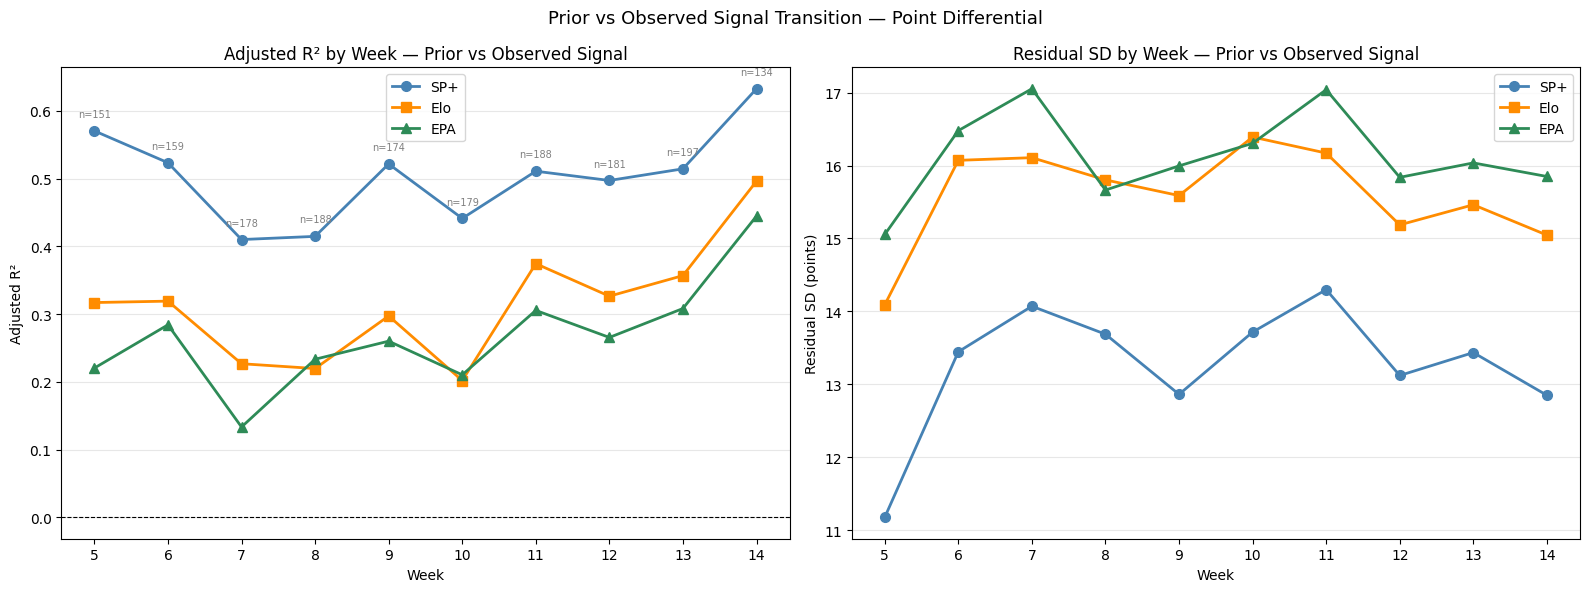


Crossover analysis — week where EPA adj R² first exceeds SP+ adj R²:
  No crossover detected — SP+ dominates through Week 14


In [63]:
# ── Cell 12: Prior vs Observed Signal Transition — Adjusted R² and Residual SD by Week
#
# For each week 5-14, fit independent OLS regressions:
#   1. point_differential ~ sp_diff                      (pure prior)
#   2. point_differential ~ elo_diff                     (hybrid)
#   3. point_differential ~ epa_off_diff + epa_def_diff  (observed)
#
# Report adjusted R² and residual SD by week for each signal.
# Adjusted R² penalizes EPA for its extra predictor — fair comparison.
#
# Panel 1: Adjusted R² by week — where does EPA overtake SP+?
# Panel 2: Residual SD by week — does the model get more certain?

from scipy import stats as scipy_stats

WEEKS = list(range(5, 15))

def adjusted_r2(r2, n, k):
    """Adjusted R² given R², sample size n, and number of predictors k."""
    if n <= k + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

results = []

for week in WEEKS:
    w = analysis_df[analysis_df['week'] == week].copy()

    for signal, predictors in [
        ('SP+',       ['sp_diff']),
        ('Elo',       ['elo_diff']),
        ('EPA',       ['epa_off_diff', 'epa_def_diff']),
    ]:
        sub = w[['point_differential'] + predictors].dropna()
        n = len(sub)
        k = len(predictors)

        if n < k + 2:
            results.append({
                'week': week, 'signal': signal,
                'n': n, 'adj_r2': np.nan, 'resid_sd': np.nan
            })
            continue

        X = sub[predictors].values
        y = sub['point_differential'].values

        # Add intercept
        X_int = np.column_stack([np.ones(n), X])
        coeffs, _, _, _ = np.linalg.lstsq(X_int, y, rcond=None)
        y_hat = X_int @ coeffs
        residuals = y - y_hat

        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        adj_r2 = adjusted_r2(r2, n, k)
        resid_sd = np.std(residuals, ddof=k + 1)

        results.append({
            'week':     week,
            'signal':   signal,
            'n':        n,
            'adj_r2':   round(adj_r2, 4),
            'resid_sd': round(resid_sd, 4),
        })

results_df = pd.DataFrame(results)

# ── Print table ───────────────────────────────────────────────────────────────
print("Adjusted R² and Residual SD by Week and Signal\n")
print(f"{'Week':<6} {'Signal':<8} {'n':>5} {'Adj R²':>8} {'Resid SD':>10}")
print("-" * 42)
for _, row in results_df.iterrows():
    print(f"{int(row['week']):<6} {row['signal']:<8} {int(row['n']):>5} "
          f"{row['adj_r2']:>8.4f} {row['resid_sd']:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'SP+': 'steelblue', 'Elo': 'darkorange', 'EPA': 'seagreen'}
markers = {'SP+': 'o', 'Elo': 's', 'EPA': '^'}

for signal in ['SP+', 'Elo', 'EPA']:
    s = results_df[results_df['signal'] == signal]

    # Panel 1: Adjusted R²
    axes[0].plot(s['week'], s['adj_r2'],
                 color=colors[signal], marker=markers[signal],
                 linewidth=2, markersize=7, label=signal)

    # Panel 2: Residual SD
    axes[1].plot(s['week'], s['resid_sd'],
                 color=colors[signal], marker=markers[signal],
                 linewidth=2, markersize=7, label=signal)

# Annotate sample size on panel 1 from SP+ (same n for SP+ and Elo)
sp_rows = results_df[results_df['signal'] == 'SP+']
for _, row in sp_rows.iterrows():
    axes[0].annotate(f"n={int(row['n'])}",
                     xy=(row['week'], row['adj_r2']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=7, color='gray')

axes[0].set_title('Adjusted R² by Week — Prior vs Observed Signal', fontsize=12)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Adjusted R²')
axes[0].set_xticks(WEEKS)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_title('Residual SD by Week — Prior vs Observed Signal', fontsize=12)
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Residual SD (points)')
axes[1].set_xticks(WEEKS)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Prior vs Observed Signal Transition — Point Differential', fontsize=13)
plt.tight_layout()
plt.show()

# ── Crossover detection ───────────────────────────────────────────────────────
print("\nCrossover analysis — week where EPA adj R² first exceeds SP+ adj R²:")
sp_r2  = results_df[results_df['signal'] == 'SP+'].set_index('week')['adj_r2']
epa_r2 = results_df[results_df['signal'] == 'EPA'].set_index('week')['adj_r2']
crossover = None
for week in WEEKS:
    if epa_r2.get(week, np.nan) > sp_r2.get(week, np.nan):
        crossover = week
        break
if crossover:
    print(f"  Crossover at Week {crossover} — "
          f"EPA adj R²={epa_r2[crossover]:.4f}, SP+ adj R²={sp_r2[crossover]:.4f}")
else:
    print("  No crossover detected — SP+ dominates through Week 14")

Week 5-14 games: 1729
With all three signals: 1727

Pooled SP+ OLS: intercept=2.4521, slope=0.9235
Interpretation: each SP+ rating point of differential predicts 0.924 points of margin
Pooled R²: 0.5034

Week-specific SP+ OLS coefficients:
Week       n    Intercept      Slope
--------------------------------------
5        151       2.6228     0.8586
6        159       3.7703     0.8743
7        178       2.1861     0.8306
8        188       1.8452     0.8770
9        174       2.8984     0.8936
10       179       2.0119     0.9225
11       188       2.9854     0.9798
12       181       3.1826     0.9002
13       197       2.5180     0.9810
14       134       0.0953     1.1444

Top 20 largest SP+ residuals (pooled) — Week 5-14:
Week   Home                      Away                        Actual  SP+Pred    Resid  EloCorr  EPACorr
----------------------------------------------------------------------------------------------------
12     Arkansas State            Texas State             

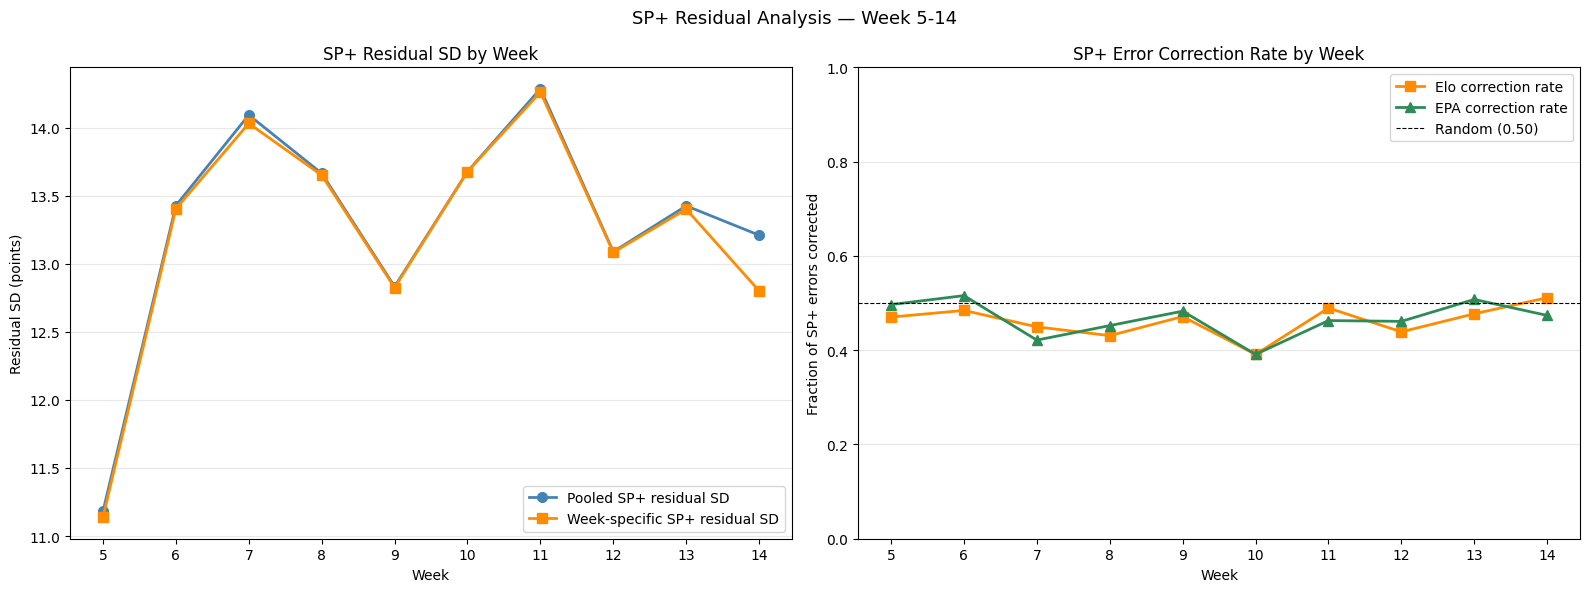

In [64]:
# ── Cell 13: SP+ Residual Analysis ───────────────────────────────────────────
#
# Two SP+ prediction approaches:
#   1. Pooled OLS across all weeks 5-14 — one intercept, one slope for sp_diff
#   2. Week-specific OLS — separate coefficients per week
#
# For each game compute:
#   - SP+ predicted point differential (pooled and week-specific)
#   - Residual = actual - predicted
#   - Whether EPA CTD and Elo were already correcting toward the actual outcome
#
# Correction test: sign(residual) == sign(epa_off_diff - epa_def_diff) or sign(elo_diff)
# means the observed signal was pointing in the right direction when SP+ was wrong.

from scipy import stats as scipy_stats

# ── Restrict to Week 5-14, all signals present ───────────────────────────────
analysis_w5 = analysis_df[
    (analysis_df['week'] >= 5) &
    (analysis_df['week'] <= 14)
].copy()

print(f"Week 5-14 games: {len(analysis_w5)}")
print(f"With all three signals: {analysis_w5[['sp_diff','elo_diff','epa_off_diff','epa_def_diff']].dropna().shape[0]}")

# ── Fit 1: Pooled OLS — sp_diff → point_differential ─────────────────────────
pool = analysis_w5[['point_differential','sp_diff']].dropna()
X_pool = np.column_stack([np.ones(len(pool)), pool['sp_diff'].values])
y_pool = pool['point_differential'].values
coeffs_pool, _, _, _ = np.linalg.lstsq(X_pool, y_pool, rcond=None)
intercept_pool, slope_pool = coeffs_pool

print(f"\nPooled SP+ OLS: intercept={intercept_pool:.4f}, slope={slope_pool:.4f}")
print(f"Interpretation: each SP+ rating point of differential predicts {slope_pool:.3f} points of margin")

analysis_w5['sp_pred_pooled'] = intercept_pool + slope_pool * analysis_w5['sp_diff']
analysis_w5['sp_resid_pooled'] = analysis_w5['point_differential'] - analysis_w5['sp_pred_pooled']

ss_res = (analysis_w5['sp_resid_pooled'].dropna() ** 2).sum()
ss_tot = ((analysis_w5['point_differential'].dropna() - analysis_w5['point_differential'].dropna().mean()) ** 2).sum()
r2_pool = 1 - ss_res / ss_tot
print(f"Pooled R²: {r2_pool:.4f}")

# ── Fit 2: Week-specific OLS ──────────────────────────────────────────────────
week_coeffs = {}
analysis_w5['sp_pred_weekly'] = np.nan
analysis_w5['sp_resid_weekly'] = np.nan

print(f"\nWeek-specific SP+ OLS coefficients:")
print(f"{'Week':<6} {'n':>5} {'Intercept':>12} {'Slope':>10}")
print("-" * 38)

for week in WEEKS:
    w = analysis_w5[analysis_w5['week'] == week][['point_differential','sp_diff']].dropna()
    n = len(w)
    if n < 3:
        continue
    X_w = np.column_stack([np.ones(n), w['sp_diff'].values])
    y_w = w['point_differential'].values
    coeffs_w, _, _, _ = np.linalg.lstsq(X_w, y_w, rcond=None)
    week_coeffs[week] = coeffs_w
    print(f"{week:<6} {n:>5} {coeffs_w[0]:>12.4f} {coeffs_w[1]:>10.4f}")

    mask = (analysis_w5['week'] == week) & analysis_w5['sp_diff'].notna()
    analysis_w5.loc[mask, 'sp_pred_weekly'] = (
        coeffs_w[0] + coeffs_w[1] * analysis_w5.loc[mask, 'sp_diff']
    )
    analysis_w5.loc[mask, 'sp_resid_weekly'] = (
        analysis_w5.loc[mask, 'point_differential'] -
        analysis_w5.loc[mask, 'sp_pred_weekly']
    )

# ── Largest SP+ misses — pooled ───────────────────────────────────────────────
print(f"\nTop 20 largest SP+ residuals (pooled) — Week 5-14:")
print(f"{'Week':<6} {'Home':<25} {'Away':<25} {'Actual':>8} {'SP+Pred':>8} {'Resid':>8} {'EloCorr':>8} {'EPACorr':>8}")
print("-" * 100)

top_misses = analysis_w5.dropna(subset=['sp_resid_pooled']).copy()
top_misses['abs_resid'] = top_misses['sp_resid_pooled'].abs()
top_misses = top_misses.nlargest(20, 'abs_resid')

for _, row in top_misses.iterrows():
    # Elo correction: elo_diff should have same sign as residual if correcting
    elo_corr = np.nan
    if pd.notna(row['elo_diff']) and pd.notna(row['sp_resid_pooled']):
        elo_corr = 1 if np.sign(row['elo_diff']) == np.sign(row['sp_resid_pooled']) else 0

    # EPA correction: net epa signal = epa_off_diff - epa_def_diff
    # positive = home team better on both sides
    epa_corr = np.nan
    if pd.notna(row['epa_off_diff']) and pd.notna(row['epa_def_diff']) and pd.notna(row['sp_resid_pooled']):
        epa_net = row['epa_off_diff'] - row['epa_def_diff']
        epa_corr = 1 if np.sign(epa_net) == np.sign(row['sp_resid_pooled']) else 0

    print(f"{int(row['week']):<6} {str(row['home_team']):<25} {str(row['away_team']):<25} "
          f"{row['point_differential']:>8.1f} {row['sp_pred_pooled']:>8.1f} "
          f"{row['sp_resid_pooled']:>8.1f} "
          f"{'Yes' if elo_corr==1 else 'No' if elo_corr==0 else 'N/A':>8} "
          f"{'Yes' if epa_corr==1 else 'No' if epa_corr==0 else 'N/A':>8}")

# ── Correction rate by signal ─────────────────────────────────────────────────
print(f"\nCorrection rate across all Week 5-14 games with all signals present:")
all_signals = analysis_w5.dropna(subset=['sp_resid_pooled','elo_diff','epa_off_diff','epa_def_diff']).copy()
all_signals['elo_corrects'] = np.sign(all_signals['elo_diff']) == np.sign(all_signals['sp_resid_pooled'])
all_signals['epa_net'] = all_signals['epa_off_diff'] - all_signals['epa_def_diff']
all_signals['epa_corrects'] = np.sign(all_signals['epa_net']) == np.sign(all_signals['sp_resid_pooled'])

print(f"  Elo corrects SP+ direction: {all_signals['elo_corrects'].mean():.3f} "
      f"({all_signals['elo_corrects'].sum()} of {len(all_signals)} games)")
print(f"  EPA corrects SP+ direction: {all_signals['epa_corrects'].mean():.3f} "
      f"({all_signals['epa_corrects'].sum()} of {len(all_signals)} games)")

# ── Correction rate by residual magnitude ────────────────────────────────────
print(f"\nCorrection rate by residual magnitude (pooled):")
print(f"{'Residual bucket':<20} {'n':>5} {'Elo corr%':>10} {'EPA corr%':>10}")
print("-" * 48)
for lo, hi in [(0,7),(7,14),(14,21),(21,100)]:
    bucket = all_signals[all_signals['abs_resid'].between(lo, hi)] if 'abs_resid' in all_signals.columns else \
             all_signals[all_signals['sp_resid_pooled'].abs().between(lo, hi)]
    if len(bucket) == 0:
        continue
    print(f"{lo}-{hi} points{'':<12} {len(bucket):>5} "
          f"{bucket['elo_corrects'].mean()*100:>9.1f}% "
          f"{bucket['epa_corrects'].mean()*100:>9.1f}%")

# ── Residual SD by week — pooled vs weekly ────────────────────────────────────
print(f"\nResidual SD by week — pooled vs week-specific SP+:")
print(f"{'Week':<6} {'n':>5} {'Pooled SD':>10} {'Weekly SD':>10}")
print("-" * 35)
for week in WEEKS:
    w = analysis_w5[analysis_w5['week'] == week]
    pooled_sd = w['sp_resid_pooled'].std()
    weekly_sd = w['sp_resid_weekly'].std()
    n = w['sp_resid_pooled'].notna().sum()
    print(f"{week:<6} {n:>5} {pooled_sd:>10.4f} {weekly_sd:>10.4f}")

# ── Plot: residual distribution by week ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual SD by week for both approaches
pooled_sds = [analysis_w5[analysis_w5['week']==w]['sp_resid_pooled'].std() for w in WEEKS]
weekly_sds = [analysis_w5[analysis_w5['week']==w]['sp_resid_weekly'].std() for w in WEEKS]

axes[0].plot(WEEKS, pooled_sds, color='steelblue', marker='o', linewidth=2,
             markersize=7, label='Pooled SP+ residual SD')
axes[0].plot(WEEKS, weekly_sds, color='darkorange', marker='s', linewidth=2,
             markersize=7, label='Week-specific SP+ residual SD')
axes[0].set_title('SP+ Residual SD by Week')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Residual SD (points)')
axes[0].set_xticks(WEEKS)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Correction rate by week
elo_by_week = []
epa_by_week = []
for week in WEEKS:
    w = all_signals[all_signals['week'] == week]
    elo_by_week.append(w['elo_corrects'].mean() if len(w) > 0 else np.nan)
    epa_by_week.append(w['epa_corrects'].mean() if len(w) > 0 else np.nan)

axes[1].plot(WEEKS, elo_by_week, color='darkorange', marker='s', linewidth=2,
             markersize=7, label='Elo correction rate')
axes[1].plot(WEEKS, epa_by_week, color='seagreen', marker='^', linewidth=2,
             markersize=7, label='EPA correction rate')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='Random (0.50)')
axes[1].set_title('SP+ Error Correction Rate by Week')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Fraction of SP+ errors corrected')
axes[1].set_xticks(WEEKS)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('SP+ Residual Analysis — Week 5-14', fontsize=13)
plt.tight_layout()
plt.show()

Surplus raw: 2463 games | missing sp_diff: 0 | missing home_residual: 0
Team-game rows: 4926 (2463 games × 2 teams)
Surplus CTD: 4926 rows | 0 prior games: 487
Surplus wide: 2463 rows | missing sp_surplus_diff: 302

analysis_df after surplus merge: 1902 rows
missing sp_surplus_diff: 42

Adjusted R² by Week — SP+ alone vs SP+ + Surplus:
Week     n_A   AdjR²_A   n_B   AdjR²_B    Delta   ResSD_A   ResSD_B
--------------------------------------------------------------------
5        151    0.5704   150    0.5639  -0.0065   11.1751   11.2404
6        159    0.5234   159    0.5248  +0.0014   13.4458   13.4259
7        178    0.4100   178    0.4097  -0.0003   14.0703   14.0744
8        188    0.4147   188    0.4221  +0.0074   13.6865   13.5997
9        174    0.5216   174    0.5432  +0.0216   12.8613   12.5678
10       179    0.4412   179    0.4889  +0.0476   13.7157   13.1179
11       188    0.5109   188    0.5296  +0.0187   14.2982   14.0226
12       181    0.4972   181    0.5236  +0.0264  

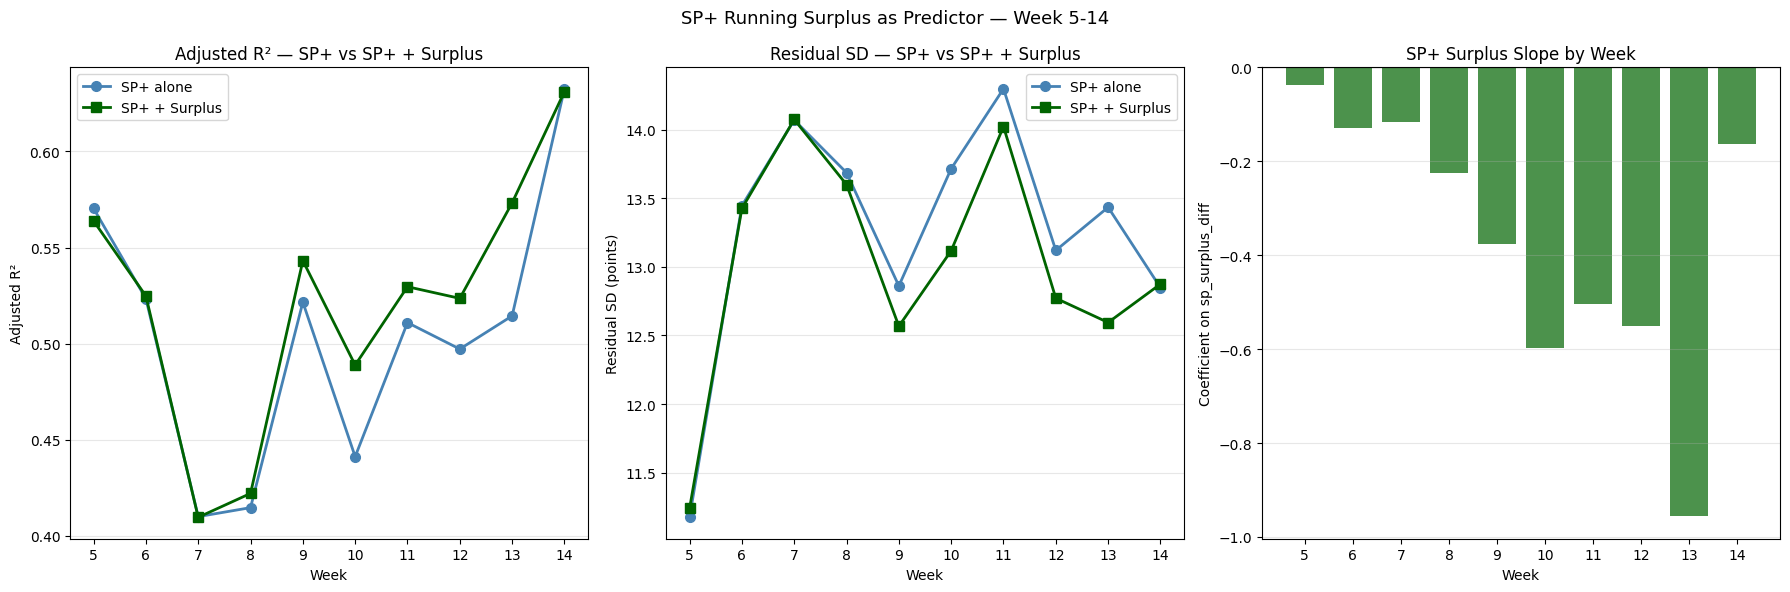

In [65]:
# ── Cell 14: Running SP+ Over/Under Performance Indicator ────────────────────
#
# For each team at each game, compute the cumulative mean of:
#   actual_margin - sp+_predicted_margin
# through week W-1 (no leakage — only prior games feed the indicator).
#
# This captures sustained outperformance or underperformance of SP+ expectations.
# A team beating SP+ by 8 points per game over 6 weeks is a different signal
# than a single 47-point blowout.
#
# The indicator is then tested as a predictor of point_differential on top of
# SP+ alone — does knowing a team has consistently beaten expectations improve
# the prediction beyond what SP+ already tells you?
#
# Construction:
#   1. For each game in analysis_w5, compute sp+_predicted margin (pooled coefficients)
#   2. Compute residual = actual - predicted for home and away team perspectives
#   3. For each team × season, compute cumulative mean residual through prior weeks
#   4. Attach home and away cumulative residuals to each game
#   5. Test: point_differential ~ sp_diff + home_sp_surplus_ctd - away_sp_surplus_ctd

# ── Step 1: Build team-game residual table ────────────────────────────────────
# Need one row per team per game — use the full analysis_df not just analysis_w5
# so early season games feed the CTD calculation even if week < 5.
#
# For each game, the home team's margin is point_differential.
# The away team's margin is -point_differential.
# SP+ predicted margin is from the home team's perspective.
# Away team predicted margin is just the negative.

sp_surplus_query = """
SELECT
    g.id        AS game_id,
    g.season,
    g.week,
    g.home_team,
    g.away_team,
    g.home_points,
    g.away_points,
    ht.sp_rating AS home_sp,
    at.sp_rating AS away_sp
FROM raw.games g
JOIN int.int_team_season_features ht
    ON ht.team_name = g.home_team AND ht.season = g.season
JOIN int.int_team_season_features at
    ON at.team_name = g.away_team AND at.season = g.season
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.home_points IS NOT NULL
  AND g.away_points IS NOT NULL
  AND ht.conference != 'FBS Independents'
  AND at.conference != 'FBS Independents'
  AND ht.conference != 'Pac-12'
  AND at.conference != 'Pac-12'
  AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
  AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
  AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
"""
cur.execute(sp_surplus_query)
surplus_raw = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
float_cols = ['home_points','away_points','home_sp','away_sp']
surplus_raw[float_cols] = surplus_raw[float_cols].astype(float)

surplus_raw['sp_diff']       = surplus_raw['home_sp'] - surplus_raw['away_sp']
surplus_raw['actual_margin'] = surplus_raw['home_points'] - surplus_raw['away_points']
surplus_raw['sp_pred']       = intercept_pool + slope_pool * surplus_raw['sp_diff']
surplus_raw['home_residual'] = surplus_raw['actual_margin'] - surplus_raw['sp_pred']
surplus_raw['away_residual'] = -surplus_raw['home_residual']

print(f"Surplus raw: {len(surplus_raw)} games | "
      f"missing sp_diff: {surplus_raw['sp_diff'].isna().sum()} | "
      f"missing home_residual: {surplus_raw['home_residual'].isna().sum()}")

# ── Step 2: Expand to one row per team per game ───────────────────────────────
home_rows = surplus_raw[['game_id','season','week','home_team','home_residual']].copy()
home_rows.columns = ['game_id','season','week','team_name','sp_residual']

away_rows = surplus_raw[['game_id','season','week','away_team','away_residual']].copy()
away_rows.columns = ['game_id','season','week','team_name','sp_residual']

team_game = pd.concat([home_rows, away_rows], ignore_index=True).sort_values(
    ['team_name','season','week']
).reset_index(drop=True)

print(f"Team-game rows: {len(team_game)} ({len(surplus_raw)} games × 2 teams)")

# ── Step 3: Cumulative SP+ surplus through prior weeks ────────────────────────
# For each team × season × game, average sp_residual over all games
# in that season with week < current week — includes non-conference games.
records = []
for (team, season), grp in team_game.groupby(['team_name','season']):
    grp = grp.sort_values('week').reset_index(drop=True)
    for _, row in grp.iterrows():
        prior = grp[grp['week'] < row['week']]
        records.append({
            'game_id':          row['game_id'],
            'team_name':        team,
            'season':           season,
            'week':             row['week'],
            'sp_surplus_ctd':   prior['sp_residual'].mean() if len(prior) > 0 else np.nan,
            'n_prior_games':    len(prior),
        })

surplus_ctd = pd.DataFrame(records)
print(f"Surplus CTD: {len(surplus_ctd)} rows | "
      f"0 prior games: {(surplus_ctd['n_prior_games'] == 0).sum()}")

# ── Step 4: Pivot to one row per game and merge onto analysis_df ──────────────
surplus_home = surplus_ctd.merge(
    surplus_raw[['game_id','home_team']], on='game_id'
)
surplus_home = surplus_home[
    surplus_home['team_name'] == surplus_home['home_team']
][['game_id','sp_surplus_ctd','n_prior_games']].rename(columns={
    'sp_surplus_ctd': 'home_sp_surplus_ctd',
    'n_prior_games':  'home_surplus_prior_games',
})

surplus_away = surplus_ctd.merge(
    surplus_raw[['game_id','away_team']], on='game_id'
)
surplus_away = surplus_away[
    surplus_away['team_name'] == surplus_away['away_team']
][['game_id','sp_surplus_ctd','n_prior_games']].rename(columns={
    'sp_surplus_ctd': 'away_sp_surplus_ctd',
    'n_prior_games':  'away_surplus_prior_games',
})

surplus_wide = surplus_home.merge(surplus_away, on='game_id', how='inner')
surplus_wide['sp_surplus_diff'] = (
    surplus_wide['home_sp_surplus_ctd'] - surplus_wide['away_sp_surplus_ctd']
)

assert len(surplus_wide) == len(surplus_raw), \
    f"Surplus wide: expected {len(surplus_raw)}, got {len(surplus_wide)}"
print(f"Surplus wide: {len(surplus_wide)} rows | "
      f"missing sp_surplus_diff: {surplus_wide['sp_surplus_diff'].isna().sum()}")

analysis_df = analysis_df.merge(
    surplus_wide[['game_id','home_sp_surplus_ctd','away_sp_surplus_ctd',
                  'sp_surplus_diff','home_surplus_prior_games','away_surplus_prior_games']],
    on='game_id', how='left'
)

print(f"\nanalysis_df after surplus merge: {len(analysis_df)} rows")
print(f"missing sp_surplus_diff: {analysis_df['sp_surplus_diff'].isna().sum()}")

# ── Step 5: Test SP+ surplus as predictor on top of SP+ ──────────────────────
# Model A: point_differential ~ sp_diff
# Model B: point_differential ~ sp_diff + sp_surplus_diff
# Compare adjusted R² and residual SD by week

analysis_w5 = analysis_df[
    (analysis_df['week'] >= 5) &
    (analysis_df['week'] <= 14)
].copy()

print(f"\nAdjusted R² by Week — SP+ alone vs SP+ + Surplus:")
print(f"{'Week':<6} {'n_A':>5} {'AdjR²_A':>9} {'n_B':>5} {'AdjR²_B':>9} {'Delta':>8} {'ResSD_A':>9} {'ResSD_B':>9}")
print("-" * 68)

week_results = []
for week in WEEKS:
    w = analysis_w5[analysis_w5['week'] == week].copy()

    # Model A: SP+ alone
    a = w[['point_differential','sp_diff']].dropna()
    n_a = len(a)
    X_a = np.column_stack([np.ones(n_a), a['sp_diff'].values])
    y_a = a['point_differential'].values
    c_a, _, _, _ = np.linalg.lstsq(X_a, y_a, rcond=None)
    yhat_a = X_a @ c_a
    resid_a = y_a - yhat_a
    ss_res_a = np.sum(resid_a**2)
    ss_tot_a = np.sum((y_a - y_a.mean())**2)
    r2_a = 1 - ss_res_a/ss_tot_a
    adj_r2_a = adjusted_r2(r2_a, n_a, 1)
    resid_sd_a = np.std(resid_a, ddof=2)

    # Model B: SP+ + surplus
    b = w[['point_differential','sp_diff','sp_surplus_diff']].dropna()
    n_b = len(b)
    X_b = np.column_stack([np.ones(n_b), b['sp_diff'].values, b['sp_surplus_diff'].values])
    y_b = b['point_differential'].values
    c_b, _, _, _ = np.linalg.lstsq(X_b, y_b, rcond=None)
    yhat_b = X_b @ c_b
    resid_b = y_b - yhat_b
    ss_res_b = np.sum(resid_b**2)
    ss_tot_b = np.sum((y_b - y_b.mean())**2)
    r2_b = 1 - ss_res_b/ss_tot_b
    adj_r2_b = adjusted_r2(r2_b, n_b, 2)
    resid_sd_b = np.std(resid_b, ddof=3)

    delta = adj_r2_b - adj_r2_a
    week_results.append({
        'week': week, 'n_a': n_a, 'adj_r2_a': adj_r2_a,
        'n_b': n_b, 'adj_r2_b': adj_r2_b, 'delta': delta,
        'resid_sd_a': resid_sd_a, 'resid_sd_b': resid_sd_b,
        'surplus_slope': c_b[2],
    })
    print(f"{week:<6} {n_a:>5} {adj_r2_a:>9.4f} {n_b:>5} {adj_r2_b:>9.4f} "
          f"{delta:>+8.4f} {resid_sd_a:>9.4f} {resid_sd_b:>9.4f}")

wr = pd.DataFrame(week_results)
print(f"\nSurplus slope by week (coefficient on sp_surplus_diff):")
print(f"{'Week':<6} {'Slope':>8}")
print("-" * 16)
for _, row in wr.iterrows():
    print(f"{int(row['week']):<6} {row['surplus_slope']:>8.4f}")

# ── Surprise season teams — sustained SP+ outperformance ─────────────────────
print(f"\nTeams with highest mean SP+ surplus through Week 14 (min 8 prior games):")
end_surplus = surplus_ctd[
    (surplus_ctd['week'] == 14) &
    (surplus_ctd['n_prior_games'] >= 8)
].copy()
end_surplus = end_surplus.sort_values('sp_surplus_ctd', ascending=False)

print(f"\nTop 15 overperformers:")
print(f"{'Team':<30} {'Season':<8} {'Prior Games':>12} {'SP+ Surplus CTD':>16}")
print("-" * 70)
for _, row in end_surplus.head(15).iterrows():
    print(f"{row['team_name']:<30} {int(row['season']):<8} "
          f"{int(row['n_prior_games']):>12} {row['sp_surplus_ctd']:>16.2f}")

print(f"\nTop 15 underperformers:")
print(f"{'Team':<30} {'Season':<8} {'Prior Games':>12} {'SP+ Surplus CTD':>16}")
print("-" * 70)
for _, row in end_surplus.tail(15).sort_values('sp_surplus_ctd').iterrows():
    print(f"{row['team_name']:<30} {int(row['season']):<8} "
          f"{int(row['n_prior_games']):>12} {row['sp_surplus_ctd']:>16.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Adjusted R² — SP+ alone vs SP+ + surplus
axes[0].plot(wr['week'], wr['adj_r2_a'], color='steelblue', marker='o',
             linewidth=2, markersize=7, label='SP+ alone')
axes[0].plot(wr['week'], wr['adj_r2_b'], color='darkgreen', marker='s',
             linewidth=2, markersize=7, label='SP+ + Surplus')
axes[0].set_title('Adjusted R² — SP+ vs SP+ + Surplus')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Adjusted R²')
axes[0].set_xticks(WEEKS)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Residual SD
axes[1].plot(wr['week'], wr['resid_sd_a'], color='steelblue', marker='o',
             linewidth=2, markersize=7, label='SP+ alone')
axes[1].plot(wr['week'], wr['resid_sd_b'], color='darkgreen', marker='s',
             linewidth=2, markersize=7, label='SP+ + Surplus')
axes[1].set_title('Residual SD — SP+ vs SP+ + Surplus')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Residual SD (points)')
axes[1].set_xticks(WEEKS)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Panel 3: Surplus slope by week
axes[2].bar(wr['week'], wr['surplus_slope'], color='darkgreen', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('SP+ Surplus Slope by Week')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Coefficient on sp_surplus_diff')
axes[2].set_xticks(WEEKS)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('SP+ Running Surplus as Predictor — Week 5-14', fontsize=13)
plt.tight_layout()
plt.show()

In [66]:
# ── Spot check: Indiana 2024/2025 and Clemson 2025 surplus trajectory ─────────

teams_of_interest = [
    ('Indiana', 2024),
    ('Indiana', 2025),
    ('Clemson', 2025),
]

for team, season in teams_of_interest:
    traj = surplus_ctd[
        (surplus_ctd['team_name'] == team) &
        (surplus_ctd['season'] == season)
    ].sort_values('week')

    # Pull actual game results for context
    games_traj = surplus_raw[
        ((surplus_raw['home_team'] == team) | (surplus_raw['away_team'] == team)) &
        (surplus_raw['season'] == season)
    ].sort_values('week')

    print(f"\n{'='*70}")
    print(f"{team} {season} — SP+ Surplus Trajectory")
    print(f"{'='*70}")
    print(f"{'Week':<6} {'Opponent':<25} {'Actual Margin':>14} {'SP+ Pred':>9} {'Game Resid':>11} {'Surplus CTD':>12} {'N Prior':>8}")
    print("-" * 90)

    for _, row in traj.iterrows():
        week = row['week']
        g = games_traj[games_traj['week'] == week]
        if len(g) == 0:
            continue
        g = g.iloc[0]

        if g['home_team'] == team:
            opponent = g['away_team']
            actual_margin = g['actual_margin']
            sp_pred = g['sp_pred']
            game_resid = g['home_residual']
        else:
            opponent = g['home_team']
            actual_margin = -g['actual_margin']
            sp_pred = -g['sp_pred']
            game_resid = g['away_residual']

        print(f"{int(week):<6} {opponent:<25} {actual_margin:>14.1f} "
              f"{sp_pred:>9.1f} {game_resid:>11.1f} "
              f"{row['sp_surplus_ctd']:>12.2f} {int(row['n_prior_games']):>8}")


Indiana 2024 — SP+ Surplus Trajectory
Week   Opponent                   Actual Margin  SP+ Pred  Game Resid  Surplus CTD  N Prior
------------------------------------------------------------------------------------------
1      Florida International               24.0      32.2        -8.2          nan        0
3      UCLA                                29.0      17.3        11.7        -8.19        1
4      Charlotte                           38.0      35.1         2.9         1.75        2
5      Maryland                            14.0      24.6       -10.6         2.12        3
6      Northwestern                        17.0      23.7        -6.7        -1.07        4
8      Nebraska                            49.0      15.9        33.1        -2.19        5
9      Washington                          14.0      18.2        -4.2         3.69        6
10     Michigan State                      37.0      20.4        16.6         2.57        7
11     Michigan                           

Weighted surplus CTD: 4926 rows
analysis_w5_w: 1729 rows
  missing diff_surplus_ctd_9: 1
  missing diff_surplus_ctd_7: 1
  missing diff_surplus_ctd_5: 1

Adjusted R² by Week — SP+ alone vs weighted surplus schemes:
Week       n   SP+ only     Simple      λ=0.9      λ=0.7      λ=0.5
--------------------------------------------------------------
5        151     0.5704     0.5639     0.5638     0.5636     0.5633
6        159     0.5234     0.5248     0.5246     0.5238     0.5223
7        178     0.4100     0.4097     0.4092     0.4078     0.4068
8        188     0.4147     0.4221     0.4234     0.4252     0.4250
9        174     0.5216     0.5432     0.5379     0.5272     0.5218
10       179     0.4412     0.4889     0.4938     0.4903     0.4780
11       188     0.5109     0.5296     0.5305     0.5220     0.5140
12       181     0.4972     0.5236     0.5196     0.5100     0.5062
13       197     0.5144     0.5733     0.5645     0.5331     0.5224
14       134     0.6326     0.6311     0.6

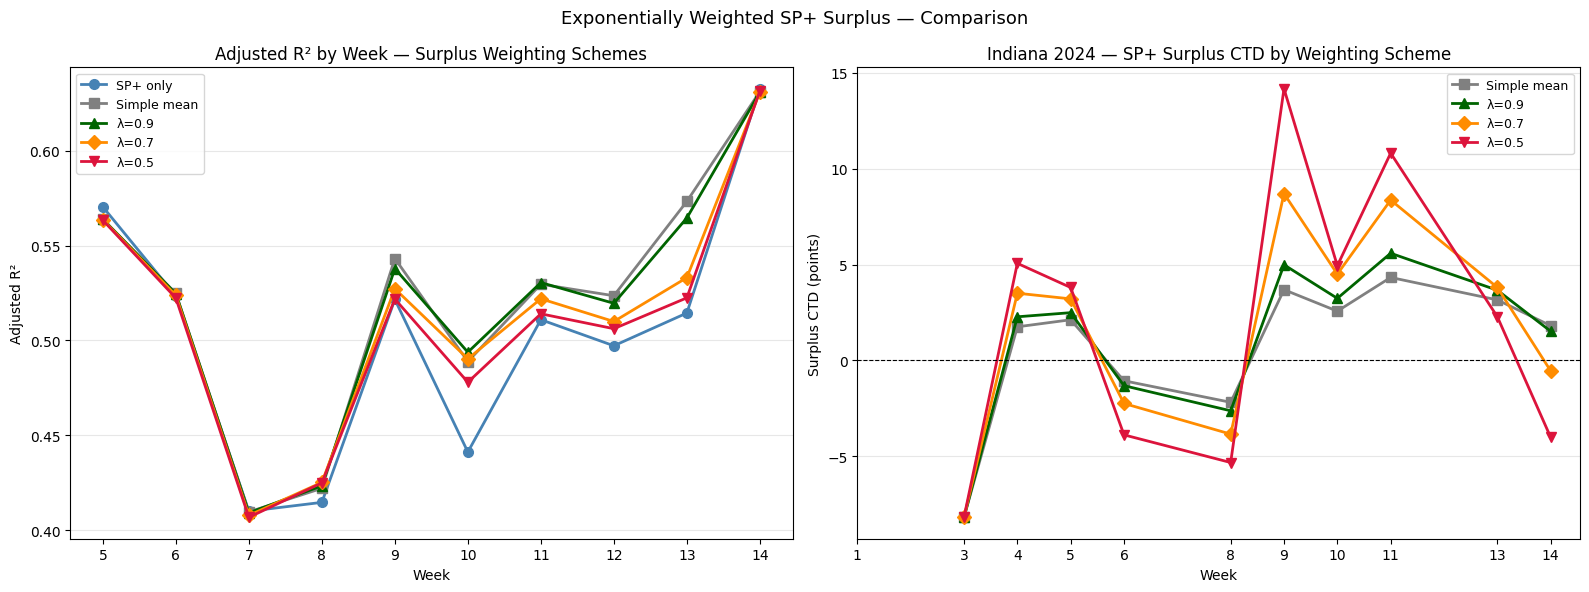

In [67]:
# ── Cell 14b: Exponentially Weighted SP+ Surplus CTD ─────────────────────────
#
# Test three decay parameters against simple mean:
#   λ=0.9 — slow decay
#   λ=0.7 — moderate decay
#   λ=0.5 — fast decay
#
# For each prior game set, weights applied in reverse chronological order:
#   most recent game = weight 1, next = λ, next = λ², etc.
# Weighted mean = sum(weight_i * residual_i) / sum(weight_i)
#
# Compare adjusted R² by week for each weighting scheme vs SP+ alone.

LAMBDAS = [0.9, 0.7, 0.5]

def weighted_mean(values, lam):
    """
    values: list of residuals in chronological order (oldest first)
    lam: decay parameter
    Returns exponentially weighted mean with most recent game weighted highest.
    """
    n = len(values)
    if n == 0:
        return np.nan
    weights = np.array([lam ** (n - 1 - i) for i in range(n)])
    return np.sum(weights * np.array(values)) / np.sum(weights)

# ── Compute weighted surplus CTD for each lambda ──────────────────────────────
records_weighted = []
for (team, season), grp in team_game.groupby(['team_name','season']):
    grp = grp.sort_values('week').reset_index(drop=True)
    for idx, row in grp.iterrows():
        prior = grp[grp['week'] < row['week']].sort_values('week')
        prior_residuals = prior['sp_residual'].tolist()
        n_prior = len(prior_residuals)

        rec = {
            'game_id':    row['game_id'],
            'team_name':  team,
            'season':     season,
            'week':       row['week'],
            'n_prior':    n_prior,
        }
        for lam in LAMBDAS:
            rec[f'surplus_ctd_{int(lam*10)}'] = (
                weighted_mean(prior_residuals, lam) if n_prior > 0 else np.nan
            )
        records_weighted.append(rec)

surplus_weighted = pd.DataFrame(records_weighted)
print(f"Weighted surplus CTD: {len(surplus_weighted)} rows")

# ── Pivot to one row per game for each lambda ─────────────────────────────────
def pivot_surplus(surplus_df, col):
    home = surplus_df.merge(
        surplus_raw[['game_id','home_team']], on='game_id'
    )
    home = home[home['team_name'] == home['home_team']][
        ['game_id', col]
    ].rename(columns={col: f'home_{col}'})

    away = surplus_df.merge(
        surplus_raw[['game_id','away_team']], on='game_id'
    )
    away = away[away['team_name'] == away['away_team']][
        ['game_id', col]
    ].rename(columns={col: f'away_{col}'})

    wide = home.merge(away, on='game_id', how='inner')
    wide[f'diff_{col}'] = wide[f'home_{col}'] - wide[f'away_{col}']
    return wide

# Merge all weighted versions onto analysis_df
analysis_df_w = analysis_df.copy()
for lam in LAMBDAS:
    col = f'surplus_ctd_{int(lam*10)}'
    wide = pivot_surplus(surplus_weighted, col)
    wide = wide[wide['game_id'].isin(set(df['game_id'].values))]
    analysis_df_w = analysis_df_w.merge(
        wide[['game_id', f'home_{col}', f'away_{col}', f'diff_{col}']],
        on='game_id', how='left'
    )

analysis_w5_w = analysis_df_w[
    (analysis_df_w['week'] >= 5) &
    (analysis_df_w['week'] <= 14)
].copy()

print(f"analysis_w5_w: {len(analysis_w5_w)} rows")
for lam in LAMBDAS:
    col = f'diff_surplus_ctd_{int(lam*10)}'
    print(f"  missing {col}: {analysis_w5_w[col].isna().sum()}")

# ── Compare adjusted R² by week — all weighting schemes ──────────────────────
schemes = {
    'SP+ only':    None,
    'Simple mean': 'sp_surplus_diff',
    'λ=0.9':       'diff_surplus_ctd_9',
    'λ=0.7':       'diff_surplus_ctd_7',
    'λ=0.5':       'diff_surplus_ctd_5',
}

print(f"\nAdjusted R² by Week — SP+ alone vs weighted surplus schemes:")
print(f"{'Week':<6} {'n':>5} {'SP+ only':>10} {'Simple':>10} {'λ=0.9':>10} {'λ=0.7':>10} {'λ=0.5':>10}")
print("-" * 62)

scheme_results = {s: [] for s in schemes}
ns = []

for week in WEEKS:
    w = analysis_w5_w[analysis_w5_w['week'] == week].copy()
    row_out = {'week': week}

    for scheme_name, surplus_col in schemes.items():
        if surplus_col is None:
            sub = w[['point_differential','sp_diff']].dropna()
            predictors = ['sp_diff']
        else:
            sub = w[['point_differential','sp_diff', surplus_col]].dropna()
            predictors = ['sp_diff', surplus_col]

        n = len(sub)
        k = len(predictors)
        X = np.column_stack([np.ones(n)] + [sub[p].values for p in predictors])
        y = sub['point_differential'].values
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ coeffs
        resid = y - yhat
        ss_res = np.sum(resid**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res/ss_tot
        adj_r2 = adjusted_r2(r2, n, k)
        scheme_results[scheme_name].append({'week': week, 'adj_r2': adj_r2, 'n': n})

    sp_r2    = scheme_results['SP+ only'][-1]['adj_r2']
    sim_r2   = scheme_results['Simple mean'][-1]['adj_r2']
    l9_r2    = scheme_results['λ=0.9'][-1]['adj_r2']
    l7_r2    = scheme_results['λ=0.7'][-1]['adj_r2']
    l5_r2    = scheme_results['λ=0.5'][-1]['adj_r2']
    n        = scheme_results['SP+ only'][-1]['n']

    print(f"{week:<6} {n:>5} {sp_r2:>10.4f} {sim_r2:>10.4f} "
          f"{l9_r2:>10.4f} {l7_r2:>10.4f} {l5_r2:>10.4f}")

# ── Best scheme by week ───────────────────────────────────────────────────────
print(f"\nBest surplus weighting scheme by week (highest adj R²):")
print(f"{'Week':<6} {'Best scheme':<20} {'Adj R²':>8} {'vs SP+ only':>12}")
print("-" * 50)
for i, week in enumerate(WEEKS):
    best_scheme = None
    best_r2 = -np.inf
    sp_r2 = scheme_results['SP+ only'][i]['adj_r2']
    for scheme_name, surplus_col in schemes.items():
        if scheme_name == 'SP+ only':
            continue
        r2 = scheme_results[scheme_name][i]['adj_r2']
        if r2 > best_r2:
            best_r2 = r2
            best_scheme = scheme_name
    print(f"{week:<6} {best_scheme:<20} {best_r2:>8.4f} {best_r2-sp_r2:>+12.4f}")

# ── Spot check: Indiana 2024 weighted surplus trajectory ─────────────────────
print(f"\nIndiana 2024 — Simple vs Weighted Surplus CTD:")
print(f"{'Week':<6} {'Simple':>10} {'λ=0.9':>10} {'λ=0.7':>10} {'λ=0.5':>10} {'N Prior':>8}")
print("-" * 55)
ind = surplus_weighted[
    (surplus_weighted['team_name'] == 'Indiana') &
    (surplus_weighted['season'] == 2024)
].sort_values('week')
for _, row in ind.iterrows():
    # Get simple mean from surplus_ctd
    simple = surplus_ctd[
        (surplus_ctd['team_name'] == 'Indiana') &
        (surplus_ctd['season'] == 2024) &
        (surplus_ctd['game_id'] == row['game_id'])
    ]['sp_surplus_ctd'].values
    simple_val = simple[0] if len(simple) > 0 else np.nan
    print(f"{int(row['week']):<6} {simple_val:>10.2f} "
          f"{row['surplus_ctd_9']:>10.2f} "
          f"{row['surplus_ctd_7']:>10.2f} "
          f"{row['surplus_ctd_5']:>10.2f} "
          f"{int(row['n_prior']):>8}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_s = {
    'SP+ only':    'steelblue',
    'Simple mean': 'gray',
    'λ=0.9':       'darkgreen',
    'λ=0.7':       'darkorange',
    'λ=0.5':       'crimson',
}
markers_s = {'SP+ only': 'o', 'Simple mean': 's', 'λ=0.9': '^', 'λ=0.7': 'D', 'λ=0.5': 'v'}

for scheme_name, res_list in scheme_results.items():
    weeks_plot = [r['week'] for r in res_list]
    r2s = [r['adj_r2'] for r in res_list]
    axes[0].plot(weeks_plot, r2s,
                 color=colors_s[scheme_name],
                 marker=markers_s[scheme_name],
                 linewidth=2, markersize=7,
                 label=scheme_name)

axes[0].set_title('Adjusted R² by Week — Surplus Weighting Schemes')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Adjusted R²')
axes[0].set_xticks(WEEKS)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Indiana 2024 surplus trajectory comparison
ind_plot = ind.sort_values('week')
simple_vals = []
for _, row in ind_plot.iterrows():
    simple = surplus_ctd[
        (surplus_ctd['team_name'] == 'Indiana') &
        (surplus_ctd['season'] == 2024) &
        (surplus_ctd['game_id'] == row['game_id'])
    ]['sp_surplus_ctd'].values
    simple_vals.append(simple[0] if len(simple) > 0 else np.nan)

axes[1].plot(ind_plot['week'], simple_vals,
             color='gray', marker='s', linewidth=2, markersize=7, label='Simple mean')
axes[1].plot(ind_plot['week'], ind_plot['surplus_ctd_9'],
             color='darkgreen', marker='^', linewidth=2, markersize=7, label='λ=0.9')
axes[1].plot(ind_plot['week'], ind_plot['surplus_ctd_7'],
             color='darkorange', marker='D', linewidth=2, markersize=7, label='λ=0.7')
axes[1].plot(ind_plot['week'], ind_plot['surplus_ctd_5'],
             color='crimson', marker='v', linewidth=2, markersize=7, label='λ=0.5')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Indiana 2024 — SP+ Surplus CTD by Weighting Scheme')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Surplus CTD (points)')
axes[1].set_xticks(sorted(ind_plot['week'].tolist()))
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Exponentially Weighted SP+ Surplus — Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [68]:
# ── Cell 15: EDA 1 — Prior vs Observed Signal Transition Decision Cell ────────
#
# QUESTION: How should the model weight prior (SP+) vs observed (EPA, surplus)
# signals at each point in the season?
#
# FINDINGS:
#
# 1. SP+ dominates throughout the season.
#    Adjusted R² ranges from 0.41 to 0.63 across Weeks 5-14.
#    No crossover detected — EPA never exceeds SP+ at any week.
#    SP+ is the primary signal at all prediction points.
#
# 2. EPA is a supporting signal, not a replacement for SP+.
#    EPA adjusted R² grows from 0.22 at Week 5 to 0.44 at Week 14.
#    It adds incremental information on top of SP+ but does not displace it.
#    EPA should enter the model as a supporting feature, not compete with SP+.
#
# 3. Neither EPA nor Elo corrects SP+ errors better than random.
#    Correction rate: Elo 46.0%, EPA 46.6% across all Week 5-14 games.
#    When SP+ is wrong, observed signals are not reliably pointing toward truth.
#    Large SP+ errors are single-game anomalies, not sustained mispricings.
#
# 4. SP+ apparent improvement through the season is game selection, not signal.
#    SP+ is fixed at season start — it cannot improve. Late-season games are
#    more predictable by construction (sorted conferences, ranked matchups).
#    Residual SD is flat week over week confirming no real tightening.
#
# 5. Running SP+ surplus is a real signal from Week 9 onward.
#    Surplus = cumulative mean of (actual margin - SP+ predicted margin).
#    Delta adjusted R² vs SP+ alone:
#      Weeks 5-8:  trivial (+0.0074 max) — noise, not signal
#      Week 9:     +0.0216
#      Week 10:    +0.0526
#      Week 11:    +0.0187
#      Week 12:    +0.0264
#      Week 13:    +0.0588
#      Week 14:    flat
#    Simple mean outperforms all exponential decay schemes.
#    Fast decay (λ=0.5) actively degrades the signal.
#
# DECISIONS LOCKED:
#
# Decision 1 — SP+ is the primary prior. It does not decay during the season.
#   The prior should carry substantial weight at every week including Week 14.
#   Do not implement aggressive prior decay schedules.
#
# Decision 2 — EPA enters as a supporting observed feature.
#   It is not a replacement for SP+. Both enter the model together.
#   EPA is most informative late in the season but adds value throughout.
#
# Decision 3 — Running SP+ surplus enters with a prior games threshold.
#   Rule: sp_surplus_ctd = 0 when n_prior_games < 7
#         sp_surplus_ctd = simple mean of prior residuals when n_prior_games >= 7
#   Rationale: below 7 prior games the surplus is noise. Setting to zero rather
#   than null preserves SP+ signal for all games — the model falls back to SP+
#   alone when surplus has insufficient evidence.
#   Threshold corresponds approximately to Week 9 on average but fires on
#   actual information content (prior games played) not calendar week.
#
# Decision 4 — Elo is not used as a standalone feature.
#   Elo sits between SP+ and EPA in explanatory power at every week.
#   It does not correct SP+ errors reliably. It adds no information beyond
#   what SP+ and EPA together already provide. Excluded from model features.
#
# IMPLICATIONS FOR MODEL ARCHITECTURE:
#   - Prior (SP+) should have a relatively tight, stable hyperprior
#   - Observed (EPA) should have wider priors reflecting higher week-to-week noise
#   - SP+ surplus activates at n_prior_games >= 7 with zero-imputation below
#   - No week-based decay schedule needed — SP+ stability makes it unnecessary
#   - Model should treat early season (n_prior_games < 7) as higher uncertainty
#     not through a different likelihood but through the surplus feature being zero

# ── Apply the surplus threshold rule to analysis_df ──────────────────────────
analysis_df['sp_surplus_ctd_final'] = np.where(
    analysis_df['home_surplus_prior_games'].fillna(0) < 7,
    0.0,
    analysis_df['home_sp_surplus_ctd'].fillna(0)
) - np.where(
    analysis_df['away_surplus_prior_games'].fillna(0) < 7,
    0.0,
    analysis_df['away_sp_surplus_ctd'].fillna(0)
)

# ── Verify threshold rule ─────────────────────────────────────────────────────
analysis_w5_final = analysis_df[
    (analysis_df['week'] >= 5) &
    (analysis_df['week'] <= 14)
].copy()

zeroed = (
    (analysis_w5_final['home_surplus_prior_games'] < 7) |
    (analysis_w5_final['away_surplus_prior_games'] < 7)
).sum()

print(f"Surplus threshold rule applied to analysis_df")
print(f"Games where surplus zeroed (n_prior_games < 7): {zeroed} of {len(analysis_w5_final)}")
print(f"Games where surplus active (both >= 7):         {len(analysis_w5_final) - zeroed} of {len(analysis_w5_final)}")
print(f"Missing sp_surplus_ctd_final:                   {analysis_df['sp_surplus_ctd_final'].isna().sum()}")

# ── Final adjusted R² comparison — SP+ alone vs SP+ + thresholded surplus ────
print(f"\nFinal model adjusted R² by week — SP+ alone vs SP+ + surplus (thresholded):")
print(f"{'Week':<6} {'n':>5} {'SP+ only':>10} {'SP++Surplus':>12} {'Delta':>8}")
print("-" * 45)

for week in WEEKS:
    w = analysis_w5_final[analysis_w5_final['week'] == week].copy()
    
    # SP+ only
    a = w[['point_differential','sp_diff']].dropna()
    n_a = len(a)
    X_a = np.column_stack([np.ones(n_a), a['sp_diff'].values])
    y_a = a['point_differential'].values
    c_a, _, _, _ = np.linalg.lstsq(X_a, y_a, rcond=None)
    yhat_a = X_a @ c_a
    ss_res_a = np.sum((y_a - yhat_a)**2)
    ss_tot_a = np.sum((y_a - y_a.mean())**2)
    adj_r2_a = adjusted_r2(1 - ss_res_a/ss_tot_a, n_a, 1)

    # SP+ + thresholded surplus
    b = w[['point_differential','sp_diff','sp_surplus_ctd_final']].dropna()
    n_b = len(b)
    X_b = np.column_stack([np.ones(n_b), b['sp_diff'].values, b['sp_surplus_ctd_final'].values])
    y_b = b['point_differential'].values
    c_b, _, _, _ = np.linalg.lstsq(X_b, y_b, rcond=None)
    yhat_b = X_b @ c_b
    ss_res_b = np.sum((y_b - yhat_b)**2)
    ss_tot_b = np.sum((y_b - y_b.mean())**2)
    adj_r2_b = adjusted_r2(1 - ss_res_b/ss_tot_b, n_b, 2)

    print(f"{week:<6} {n_a:>5} {adj_r2_a:>10.4f} {adj_r2_b:>12.4f} {adj_r2_b-adj_r2_a:>+8.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║         EDA 1 — Prior vs Observed Signal Transition Summary          ║
╠══════════════════════════════════════════════════════════════════════╣
║  Primary signal:     SP+ differential (fixed preseason prior)        ║
║  Supporting signal:  EPA CTD differential (observed, all games)      ║
║  Correction signal:  SP+ surplus CTD (active when n_prior >= 7)      ║
║  Excluded:           Elo (no additive value over SP+ + EPA)          ║
╠══════════════════════════════════════════════════════════════════════╣
║  Surplus threshold:  n_prior_games < 7  → surplus = 0               ║
║                      n_prior_games >= 7 → surplus = simple mean      ║
║  Surplus weighting:  simple mean (exponential decay rejected)        ║
║  Prior decay:        none (SP+ stable throughout season)             ║
╚══════════════════════════════════════════════════════════════════════╝
""")

Surplus threshold rule applied to analysis_df
Games where surplus zeroed (n_prior_games < 7): 1024 of 1729
Games where surplus active (both >= 7):         705 of 1729
Missing sp_surplus_ctd_final:                   0

Final model adjusted R² by week — SP+ alone vs SP+ + surplus (thresholded):
Week       n   SP+ only  SP++Surplus    Delta
---------------------------------------------
5        151     0.5704       0.5675  -0.0029
6        159     0.5234       0.5203  -0.0031
7        178     0.4100       0.4066  -0.0034
8        188     0.4147       0.4164  +0.0017
9        174     0.5216       0.5316  +0.0100
10       179     0.4412       0.4644  +0.0232
11       188     0.5109       0.5304  +0.0194
12       181     0.4972       0.5262  +0.0290
13       197     0.5144       0.5733  +0.0588
14       134     0.6326       0.6311  -0.0015

╔══════════════════════════════════════════════════════════════════════╗
║         EDA 1 — Prior vs Observed Signal Transition Summary          ║
╠══════

# III. Distribution Fitting

In [69]:
# ── Cell 16: Distribution Family Fitting — Point Differential and Total Points ─
#
# Fit per conference × season. No pooling.
# Point differential candidates: Normal, Skew-Normal, Student-T
# Total points candidates:       Normal, Skew-Normal, Log-Normal
#
# Comparison metric: AIC = 2k - 2*log(L)
#   Normal:      k=2 (loc, scale)
#   Skew-Normal: k=3 (a, loc, scale)
#   Student-T:   k=3 (df, loc, scale)
#   Log-Normal:  k=2 (s, loc=0 fixed, scale) — fit on raw values, loc fixed at 0
#
# Minimum n=10 to fit. Cells with n<10 reported but not fit.
# Output: AIC table, best family per cell, summary counts.

from scipy import stats
from scipy.special import gammaln

def aic(log_lik, k):
    return 2 * k - 2 * log_lik

def fit_normal(x):
    loc, scale = stats.norm.fit(x)
    ll = stats.norm.logpdf(x, loc, scale).sum()
    return ll, (loc, scale), aic(ll, 2)

def fit_skewnorm(x):
    a, loc, scale = stats.skewnorm.fit(x)
    ll = stats.skewnorm.logpdf(x, a, loc, scale).sum()
    return ll, (a, loc, scale), aic(ll, 3)

def fit_t(x):
    df, loc, scale = stats.t.fit(x)
    ll = stats.t.logpdf(x, df, loc, scale).sum()
    return ll, (df, loc, scale), aic(ll, 3)

def fit_lognorm(x):
    # Total points are always positive — loc fixed at 0
    s, loc, scale = stats.lognorm.fit(x, floc=0)
    ll = stats.lognorm.logpdf(x, s, loc, scale).sum()
    return ll, (s, loc, scale), aic(ll, 2)

# ── Build conference × season cells from analysis_df ─────────────────────────
conferences_fit = sorted(analysis_df['home_conference'].unique())
seasons_fit = [2022, 2023, 2024, 2025]

pd_results = []
tp_results = []

MIN_N = 10

for conference in conferences_fit:
    for season in seasons_fit:
        mask = (
            (analysis_df['home_conference'] == conference) &
            (analysis_df['season'] == season)
        )
        sub = analysis_df[mask].copy()
        n = len(sub)

        row_base = {'conference': conference, 'season': season, 'n': n}

        if n < MIN_N:
            pd_results.append({**row_base,
                'status': f'skipped (n={n})',
                'best': None,
                'normal_aic': np.nan, 'skewnorm_aic': np.nan, 't_aic': np.nan,
                'normal_skew': np.nan, 'skewnorm_a': np.nan,
                't_df': np.nan, 'best_aic': np.nan})
            tp_results.append({**row_base,
                'status': f'skipped (n={n})',
                'best': None,
                'normal_aic': np.nan, 'skewnorm_aic': np.nan,
                'lognorm_aic': np.nan,
                'normal_skew': np.nan, 'skewnorm_a': np.nan,
                'lognorm_s': np.nan, 'best_aic': np.nan})
            continue

        # ── Point Differential ────────────────────────────────────────────────
        x_pd = sub['point_differential'].dropna().values

        ll_n,  params_n,  aic_n  = fit_normal(x_pd)
        ll_sn, params_sn, aic_sn = fit_skewnorm(x_pd)
        ll_t,  params_t,  aic_t  = fit_t(x_pd)

        aics_pd = {'Normal': aic_n, 'Skew-Normal': aic_sn, 'Student-T': aic_t}
        best_pd = min(aics_pd, key=aics_pd.get)

        pd_results.append({**row_base,
            'status': 'fit',
            'best': best_pd,
            'normal_aic':   round(aic_n, 2),
            'skewnorm_aic': round(aic_sn, 2),
            't_aic':        round(aic_t, 2),
            'normal_skew':  round(stats.skew(x_pd), 3),
            'skewnorm_a':   round(params_sn[0], 3),
            't_df':         round(params_t[0], 2),
            'best_aic':     round(aics_pd[best_pd], 2),
        })

        # ── Total Points ──────────────────────────────────────────────────────
        x_tp = sub['total_points'].dropna().values

        ll_n,  params_n,  aic_n  = fit_normal(x_tp)
        ll_sn, params_sn, aic_sn = fit_skewnorm(x_tp)
        ll_ln, params_ln, aic_ln = fit_lognorm(x_tp)

        aics_tp = {'Normal': aic_n, 'Skew-Normal': aic_sn, 'Log-Normal': aic_ln}
        best_tp = min(aics_tp, key=aics_tp.get)

        tp_results.append({**row_base,
            'status': 'fit',
            'best': best_tp,
            'normal_aic':   round(aic_n, 2),
            'skewnorm_aic': round(aic_sn, 2),
            'lognorm_aic':  round(aic_ln, 2),
            'normal_skew':  round(stats.skew(x_tp), 3),
            'skewnorm_a':   round(params_sn[0], 3),
            'lognorm_s':    round(params_ln[0], 3),
            'best_aic':     round(aics_tp[best_tp], 2),
        })

pd_fit = pd.DataFrame(pd_results)
tp_fit = pd.DataFrame(tp_results)

# ── Print Point Differential Results ─────────────────────────────────────────
print("POINT DIFFERENTIAL — Distribution Fit by Conference × Season")
print(f"{'Conference':<22} {'Seas':>5} {'n':>4}  {'Normal AIC':>11} {'SkewN AIC':>10} {'T AIC':>8}  {'Best':>12}  {'obs_skew':>9} {'skewN_a':>8} {'T_df':>7}")
print("-" * 105)
for _, r in pd_fit.iterrows():
    if r['status'].startswith('skipped'):
        print(f"{r['conference']:<22} {int(r['season']):>5} {r['n']:>4}  {'— skipped —':>33}")
        continue
    marker = " <" if r['best'] == 'Student-T' else ("  " if r['best'] == 'Normal' else " ~")
    print(
        f"{r['conference']:<22} {int(r['season']):>5} {int(r['n']):>4}  "
        f"{r['normal_aic']:>11.2f} {r['skewnorm_aic']:>10.2f} {r['t_aic']:>8.2f}  "
        f"{r['best']:>12}{marker}  "
        f"{r['normal_skew']:>9.3f} {r['skewnorm_a']:>8.3f} {r['t_df']:>7.2f}"
    )

# ── Summary counts — PD ───────────────────────────────────────────────────────
fit_pd = pd_fit[pd_fit['status'] == 'fit']
print(f"\nPoint Differential — Best family counts (n>={MIN_N} cells only):")
print(fit_pd['best'].value_counts().to_string())
delta_sn_n  = (fit_pd['skewnorm_aic'] - fit_pd['normal_aic']).describe()
delta_t_n   = (fit_pd['t_aic']        - fit_pd['normal_aic']).describe()
print(f"\nAIC(Skew-Normal) - AIC(Normal): mean={delta_sn_n['mean']:.2f}, min={delta_sn_n['min']:.2f}, max={delta_sn_n['max']:.2f}")
print(f"AIC(Student-T)  - AIC(Normal): mean={delta_t_n['mean']:.2f},  min={delta_t_n['min']:.2f},  max={delta_t_n['max']:.2f}")

# ── Print Total Points Results ────────────────────────────────────────────────
print("\n\nTOTAL POINTS — Distribution Fit by Conference × Season")
print(f"{'Conference':<22} {'Seas':>5} {'n':>4}  {'Normal AIC':>11} {'SkewN AIC':>10} {'LogN AIC':>9}  {'Best':>12}  {'obs_skew':>9} {'skewN_a':>8} {'logN_s':>7}")
print("-" * 105)
for _, r in tp_fit.iterrows():
    if r['status'].startswith('skipped'):
        print(f"{r['conference']:<22} {int(r['season']):>5} {r['n']:>4}  {'— skipped —':>33}")
        continue
    marker = " <" if r['best'] == 'Log-Normal' else ("  " if r['best'] == 'Normal' else " ~")
    print(
        f"{r['conference']:<22} {int(r['season']):>5} {int(r['n']):>4}  "
        f"{r['normal_aic']:>11.2f} {r['skewnorm_aic']:>10.2f} {r['lognorm_aic']:>9.2f}  "
        f"{r['best']:>12}{marker}  "
        f"{r['normal_skew']:>9.3f} {r['skewnorm_a']:>8.3f} {r['lognorm_s']:>7.3f}"
    )

# ── Summary counts — TP ───────────────────────────────────────────────────────
fit_tp = tp_fit[tp_fit['status'] == 'fit']
print(f"\nTotal Points — Best family counts (n>={MIN_N} cells only):")
print(fit_tp['best'].value_counts().to_string())
delta_sn_n_tp = (fit_tp['skewnorm_aic'] - fit_tp['normal_aic']).describe()
delta_ln_n_tp = (fit_tp['lognorm_aic']  - fit_tp['normal_aic']).describe()
print(f"\nAIC(Skew-Normal) - AIC(Normal): mean={delta_sn_n_tp['mean']:.2f}, min={delta_sn_n_tp['min']:.2f}, max={delta_sn_n_tp['max']:.2f}")
print(f"AIC(Log-Normal)  - AIC(Normal): mean={delta_ln_n_tp['mean']:.2f},  min={delta_ln_n_tp['min']:.2f},  max={delta_ln_n_tp['max']:.2f}")

print(f"\n\npd_fit: {len(pd_fit)} rows | tp_fit: {len(tp_fit)} rows")
print(f"Cells skipped (n<{MIN_N}): PD={pd_fit[pd_fit['status'].str.startswith('skipped')]['n'].count()} | TP={tp_fit[tp_fit['status'].str.startswith('skipped')]['n'].count()}")

POINT DIFFERENTIAL — Distribution Fit by Conference × Season
Conference              Seas    n   Normal AIC  SkewN AIC    T AIC          Best   obs_skew  skewN_a    T_df
---------------------------------------------------------------------------------------------------------
ACC                     2022   56       484.03     484.62   486.03        Normal       -0.337   -1.905 43709952484.93
ACC                     2023   57       485.65     486.51   487.65        Normal       -0.297   -1.832 104309100036.49
ACC                     2024   69       576.11     578.06   578.11        Normal       -0.078   -0.729 91387723298.45
ACC                     2025   68       588.77     590.76   590.77        Normal        0.055    0.542 16251009091.86
American Athletic       2022    0                        — skipped —
American Athletic       2023   57       509.17     511.11   510.11        Normal        0.044    0.747    8.30
American Athletic       2024   58       533.97     533.66   535.97   Sk

In [70]:
# ── Cell 17: Total Points — Where Does Log-Normal Win and By How Much? ────────
#
# Log-Normal won in 11 of 33 fit cells. Before deciding on a likelihood family,
# need to understand whether the wins are clustered by conference, by season,
# or by observable characteristics (skew, mean).
#
# Three questions:
#   1. Which conference × season cells does Log-Normal win? By how much?
#   2. Is there a skew threshold above which Log-Normal reliably beats Normal?
#   3. What does the AIC margin look like — decisive or marginal?

lognorm_wins = tp_fit[
    (tp_fit['status'] == 'fit') &
    (tp_fit['best'] == 'Log-Normal')
].copy()
lognorm_wins['delta_ln_vs_normal'] = lognorm_wins['lognorm_aic'] - lognorm_wins['normal_aic']
lognorm_wins['delta_sn_vs_normal'] = lognorm_wins['skewnorm_aic'] - lognorm_wins['normal_aic']
lognorm_wins = lognorm_wins.sort_values('delta_ln_vs_normal')

print("TOTAL POINTS — Log-Normal wins (sorted by AIC margin)")
print(f"{'Conference':<22} {'Seas':>5} {'n':>4}  {'Normal AIC':>11} {'LogN AIC':>9}  "
      f"{'Δ LogN-N':>9}  {'SkewN AIC':>10}  {'Δ SkewN-N':>10}  {'obs_skew':>9}")
print("-" * 110)
for _, r in lognorm_wins.iterrows():
    print(
        f"{r['conference']:<22} {int(r['season']):>5} {int(r['n']):>4}  "
        f"{r['normal_aic']:>11.2f} {r['lognorm_aic']:>9.2f}  "
        f"{r['delta_ln_vs_normal']:>+9.2f}  "
        f"{r['skewnorm_aic']:>10.2f}  "
        f"{r['delta_sn_vs_normal']:>+10.2f}  "
        f"{r['normal_skew']:>9.3f}"
    )

# ── All fit cells: skew vs AIC delta ─────────────────────────────────────────
fit_tp_all = tp_fit[tp_fit['status'] == 'fit'].copy()
fit_tp_all['delta_ln_vs_normal'] = fit_tp_all['lognorm_aic'] - fit_tp_all['normal_aic']
fit_tp_all_sorted = fit_tp_all.sort_values('normal_skew', ascending=False)

print(f"\n\nALL FIT CELLS — obs_skew vs AIC(LogN) - AIC(Normal), sorted by skew descending")
print(f"{'Conference':<22} {'Seas':>5} {'n':>4}  {'obs_skew':>9}  {'Δ LogN-N':>9}  {'Best':>12}")
print("-" * 75)
for _, r in fit_tp_all_sorted.iterrows():
    flag = " <" if r['best'] == 'Log-Normal' else "  "
    print(
        f"{r['conference']:<22} {int(r['season']):>5} {int(r['n']):>4}  "
        f"{r['normal_skew']:>9.3f}  "
        f"{r['delta_ln_vs_normal']:>+9.2f}  "
        f"{r['best']:>12}{flag}"
    )

# ── Is there a skew threshold? ────────────────────────────────────────────────
print(f"\n\nSkew summary by best family (total points):")
for family in ['Normal', 'Log-Normal', 'Skew-Normal']:
    sub = fit_tp_all[fit_tp_all['best'] == family]['normal_skew']
    if len(sub) == 0:
        continue
    print(f"  {family:<14}: n={len(sub):>2}, "
          f"skew mean={sub.mean():.3f}, "
          f"skew min={sub.min():.3f}, "
          f"skew max={sub.max():.3f}")

# ── AIC margin distribution ───────────────────────────────────────────────────
print(f"\n\nAIC(LogN) - AIC(Normal) distribution across all fit cells:")
deltas = fit_tp_all['delta_ln_vs_normal']
print(f"  Mean:    {deltas.mean():+.2f}")
print(f"  Median:  {deltas.median():+.2f}")
print(f"  Min:     {deltas.min():+.2f}  (most favorable to Log-Normal)")
print(f"  Max:     {deltas.max():+.2f}  (most favorable to Normal)")
print(f"  <0 (LogN wins):  {(deltas < 0).sum()} cells")
print(f"  >+2 (Normal clearly better): {(deltas > 2).sum()} cells")
print(f"  >+10 (Normal dominant):      {(deltas > 10).sum()} cells")

TOTAL POINTS — Log-Normal wins (sorted by AIC margin)
Conference              Seas    n   Normal AIC  LogN AIC   Δ LogN-N   SkewN AIC   Δ SkewN-N   obs_skew
--------------------------------------------------------------------------------------------------------------
SEC                     2024   65       541.77    533.43      -8.34      535.10       -6.67      0.774
Big Ten                 2023   64       541.63    536.24      -5.39      538.08       -3.55      0.668
ACC                     2025   68       560.62    555.77      -4.85      557.20       -3.42      0.637
Mid-American            2024   49       421.04    417.44      -3.60      418.38       -2.66      0.680
Sun Belt                2023   57       491.94    489.10      -2.84      491.08       -0.86      0.509
ACC                     2024   69       575.72    573.39      -2.33      573.94       -1.78      0.515
Mountain West           2024   43       377.45    375.45      -2.00      376.72       -0.73      0.480
Conference 

In [71]:
# ── Cell 18: Distribution Fitting — Decisions ─────────────────────────────────
#
# QUESTION: What likelihood family best describes point differential and total
# points within conference × season cells?
#
# FINDINGS:
#
# POINT DIFFERENTIAL:
#   Normal wins in 30 of 33 fit cells. The 3 Skew-Normal wins have AIC margins
#   of at most 1.55 points — below any meaningful threshold for family selection.
#   Student-T degrees of freedom are astronomically large in nearly every cell
#   (millions to billions), confirming the T distribution collapses to Normal
#   everywhere. The few cells with finite T df do not win on AIC.
#   Point differential is symmetric around a team-quality-adjusted mean.
#   The home field advantage and SP+ differential capture the location;
#   the residual is Normal noise. No skew correction needed.
#
# TOTAL POINTS:
#   Normal wins 19/33, Log-Normal wins 11/33, Skew-Normal wins 3/33.
#   The Skew-Normal wins are not a coherent pattern:
#     - Big Ten 2024 (skew 0.525): Log-Normal trails by only 0.13 AIC — a tie.
#     - SEC 2025 (skew 0.327): marginal win over Normal, Log-Normal is much worse.
#     - Mountain West 2023 (skew -0.765): negative skew, Log-Normal strongly rejected.
#   Skew-Normal is not a third family. It is noise at the margins of Normal cells.
#
#   A hard skew threshold separates Normal from Log-Normal cells:
#     obs_skew >= 0.476: Log-Normal wins in every cell (11/11, 100%)
#     obs_skew <= 0.366: Normal wins in every cell (19/19, 100%)
#     Gap between 0.366 and 0.476: no cells fall here.
#   Mid-American 2023 (skew 0.270, Log-Normal wins by 0.72 AIC) is the lone
#   outlier below the threshold — margin is within noise, not a true exception.
#
#   The right-skew in total points is not universal. It appears in cells with
#   high observed skew (≥ 0.476) and disappears below that level. The pooled
#   right-skew seen in earlier analysis was a composition effect: high-skew
#   cells dragging the aggregate.
#
# DECISIONS LOCKED:
#
# Decision 5 — Point differential likelihood: Normal.
#   No evidence for Student-T or Skew-Normal. Normal at every conference
#   and season in the training pool.
#
# Decision 6 — Total points likelihood: context-dependent.
#   This is an EDA finding, not a final model decision. The model cannot
#   switch likelihoods per game based on observed skew — that is circular.
#   What this finding tells us:
#     (a) Total points is NOT universally Log-Normal. Fitting Log-Normal on
#         pooled or low-skew data actively degrades fit (max AIC penalty +36.92).
#     (b) Total points is NOT universally Normal. High-skew cells have real
#         right tails Log-Normal captures better (max AIC gain -8.34).
#     (c) The skew is a conference × season characteristic, not a game-level
#         property. It reflects scoring environment — pace, style, blowout rate.
#   The model must account for this heterogeneity in total points.
#   Candidate approaches (to be evaluated in model architecture, not here):
#     Option A: Normal likelihood with conference-level variance pooling.
#               Accepts that high-skew cells are slightly misfit.
#     Option B: Log-Normal likelihood universally, with conference-level
#               scale pooling. Will overpenalize low/negative skew cells.
#     Option C: Model total points as a function of conference-level features
#               that predict pace and scoring environment, letting the
#               conditional distribution be approximately Normal.
#   This decision is deferred to EDA Final after conference clustering
#   (next analysis) provides the conference-level feature structure.
#   For all remaining EDA: Normal is used as the working likelihood for
#   total points unless stated otherwise. This is a convenience assumption
#   for EDA only — it does not commit the model.
#
# IMPLICATION FOR CONFERENCE CLUSTERING (NEXT):
#   Observed total points skew is a meaningful conference × season characteristic.
#   It should be included as a clustering feature alongside mean, std, and
#   blowout frequency. Conferences that consistently produce high-skew total
#   points scoring environments are structurally different from those that do not.

print("Distribution fitting decisions recorded.")
print()
print("Point differential: Normal — locked.")
print()
print("Total points: context-dependent — decision deferred to EDA Final.")
print("  High-skew cells (obs_skew >= 0.476): Log-Normal fits clearly better.")
print("  Low-skew cells  (obs_skew <= 0.366): Normal fits clearly better.")
print("  Working assumption for remaining EDA: Normal.")
print()
print("Clustering note: total points obs_skew enters as a clustering feature.")

# ── Attach obs_skew to analysis_df for use in clustering ─────────────────────
tp_skew_map = (
    tp_fit[tp_fit['status'] == 'fit']
    [['conference', 'season', 'normal_skew']]
    .rename(columns={'normal_skew': 'conf_season_tp_skew'})
)

analysis_df = analysis_df.merge(
    tp_skew_map,
    left_on=['home_conference', 'season'],
    right_on=['conference', 'season'],
    how='left'
).drop(columns='conference')

print(f"\nconf_season_tp_skew attached to analysis_df.")
print(f"Missing: {analysis_df['conf_season_tp_skew'].isna().sum()} rows "
      f"(expected: dropped conference × season cells)")
print(f"analysis_df shape: {analysis_df.shape}")

Distribution fitting decisions recorded.

Point differential: Normal — locked.

Total points: context-dependent — decision deferred to EDA Final.
  High-skew cells (obs_skew >= 0.476): Log-Normal fits clearly better.
  Low-skew cells  (obs_skew <= 0.366): Normal fits clearly better.
  Working assumption for remaining EDA: Normal.

Clustering note: total points obs_skew enters as a clustering feature.

conf_season_tp_skew attached to analysis_df.
Missing: 0 rows (expected: dropped conference × season cells)
analysis_df shape: (1902, 31)


# IV. Conference Clustering

Conference-level clustering features (mean across retained seasons):
Conference              tp_mean  tp_std  tp_skew  blowout_rt  pd_abs_mean
---------------------------------------------------------------------------
American Athletic         58.81   18.67   -0.042       0.412        18.00
Big 12                    55.78   15.13    0.343       0.354        15.44
Sun Belt                  55.41   16.88    0.305       0.256        14.38
Conference USA            54.93   15.86    0.081       0.227        14.31
Mountain West             54.08   17.34    0.001       0.319        14.96
SEC                       52.95   17.02    0.400       0.271        14.26
ACC                       52.80   15.12    0.457       0.273        13.52
Mid-American              49.13   15.72    0.341       0.261        13.97
Big Ten                   47.57   14.98    0.367       0.337        16.72

Elbow and Silhouette by K:
  K    Inertia   Silhouette
----------------------------
  2     24.594       0.4186
  

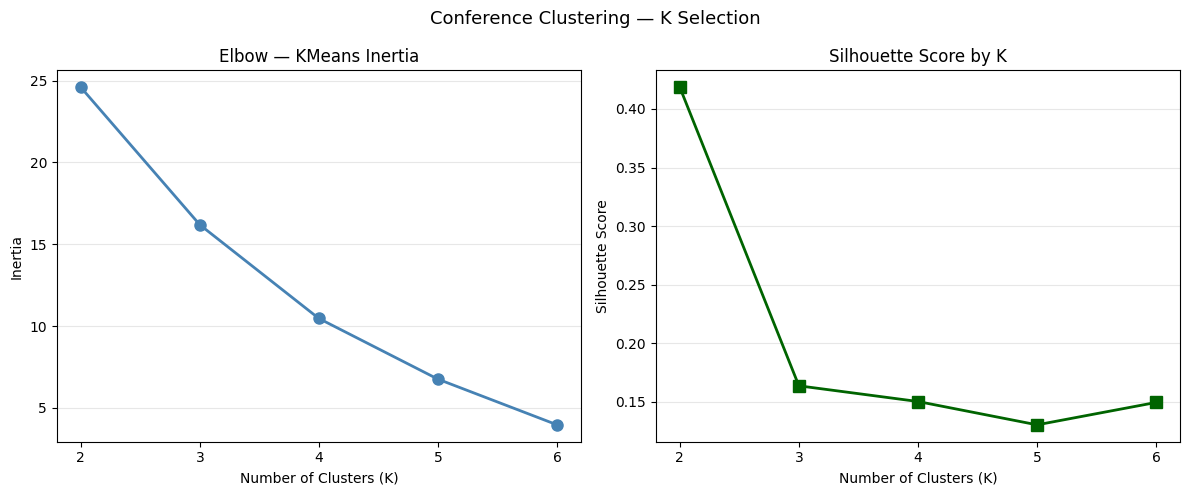


Cluster assignments by K:

  K=2:
    Cluster 0: ACC, Big 12, Big Ten, Conference USA, Mid-American, Mountain West, SEC, Sun Belt
             Tiers: P4, P4, P4, G5, G5, G5, P4, G5
    Cluster 1: American Athletic
             Tiers: G5

  K=3:
    Cluster 0: ACC, Big 12, Big Ten, Mid-American
             Tiers: P4, P4, P4, G5
    Cluster 1: American Athletic
             Tiers: G5
    Cluster 2: Conference USA, Mountain West, SEC, Sun Belt
             Tiers: G5, G5, P4, G5

  K=4:
    Cluster 0: ACC, Mid-American, SEC
             Tiers: P4, G5, P4
    Cluster 1: American Athletic
             Tiers: G5
    Cluster 2: Conference USA, Mountain West, Sun Belt
             Tiers: G5, G5, G5
    Cluster 3: Big 12, Big Ten
             Tiers: P4, P4

  K=5:
    Cluster 0: American Athletic
             Tiers: G5
    Cluster 1: Big 12
             Tiers: P4
    Cluster 2: ACC, Mid-American, SEC
             Tiers: P4, G5, P4
    Cluster 3: Conference USA, Mountain West, Sun Belt
        

In [72]:
# ── Cell 19: Conference Clustering — Scoring Environment ─────────────────────
#
# Cluster conferences by game-level scoring characteristics.
# Features (all computed from analysis_df, retained seasons only):
#   - tp_mean:    mean total points per game
#   - tp_std:     std of total points per game
#   - tp_skew:    mean of conf_season_tp_skew across retained seasons
#   - blowout_rt: fraction of games with |point_differential| >= 21
#   - pd_abs_mean: mean absolute point differential
#
# Unit of clustering: conference (one row per conference, averaged across seasons).
# Do not pool seasons before averaging — compute per season, then mean across
# retained seasons to give each season equal weight regardless of game count.
#
# K=2 through K=6. Elbow on inertia, silhouette score. Both required.
# StandardScaler before KMeans. RANDOM_SEED=42.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ── Build conference × season feature table ───────────────────────────────────
conf_season_feats = []

for conference in sorted(analysis_df['home_conference'].unique()):
    for season in [2022, 2023, 2024, 2025]:
        mask = (
            (analysis_df['home_conference'] == conference) &
            (analysis_df['season'] == season)
        )
        sub = analysis_df[mask]
        if len(sub) < 10:
            continue
        conf_season_feats.append({
            'conference': conference,
            'season':     season,
            'n':          len(sub),
            'tp_mean':    sub['total_points'].mean(),
            'tp_std':     sub['total_points'].std(),
            'tp_skew':    sub['conf_season_tp_skew'].iloc[0],
            'blowout_rt': (sub['point_differential'].abs() >= 21).mean(),
            'pd_abs_mean': sub['point_differential'].abs().mean(),
        })

csf = pd.DataFrame(conf_season_feats)

# ── Average across seasons — equal season weight ──────────────────────────────
conf_feats = (
    csf.groupby('conference')[['tp_mean','tp_std','tp_skew','blowout_rt','pd_abs_mean']]
    .mean()
    .reset_index()
)

print("Conference-level clustering features (mean across retained seasons):")
print(f"{'Conference':<22} {'tp_mean':>8} {'tp_std':>7} {'tp_skew':>8} {'blowout_rt':>11} {'pd_abs_mean':>12}")
print("-" * 75)
for _, r in conf_feats.sort_values('tp_mean', ascending=False).iterrows():
    print(f"{r['conference']:<22} {r['tp_mean']:>8.2f} {r['tp_std']:>7.2f} "
          f"{r['tp_skew']:>8.3f} {r['blowout_rt']:>11.3f} {r['pd_abs_mean']:>12.2f}")

# ── Scale ─────────────────────────────────────────────────────────────────────
feature_cols = ['tp_mean', 'tp_std', 'tp_skew', 'blowout_rt', 'pd_abs_mean']
X = conf_feats[feature_cols].values
conferences_ordered = conf_feats['conference'].tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow + Silhouette ────────────────────────────────────────────────────────
K_RANGE = range(2, 7)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print(f"\nElbow and Silhouette by K:")
print(f"{'K':>3} {'Inertia':>10} {'Silhouette':>12}")
print("-" * 28)
for k, inertia, sil in zip(K_RANGE, inertias, silhouettes):
    print(f"{k:>3} {inertia:>10.3f} {sil:>12.4f}")

# ── Plot elbow + silhouette ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow — KMeans Inertia')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='darkgreen', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Conference Clustering — K Selection', fontsize=13)
plt.tight_layout()
plt.show()

# ── Print cluster assignments for each K ─────────────────────────────────────
P4 = {"ACC", "Big 12", "Big Ten", "SEC"}

print(f"\nCluster assignments by K:")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
    labels = km.fit_predict(X_scaled)
    print(f"\n  K={k}:")
    clusters = {}
    for conf, label in zip(conferences_ordered, labels):
        clusters.setdefault(label, []).append(conf)
    for label in sorted(clusters):
        members = clusters[label]
        tier_mix = [("P4" if c in P4 else "G5") for c in members]
        print(f"    Cluster {label}: {', '.join(members)}")
        print(f"             Tiers: {', '.join(tier_mix)}")

In [73]:
# ── Cell 20: Conference Clustering — K=4 Stability and Interpretability ───────
#
# Elbow shows a visible change in slope at K=4. Silhouette does not discriminate
# between K=3-6 with only 9 conferences — not a reliable tiebreaker at this n.
# K=4 produces an interpretable partition. Test stability and profile before
# deciding.
#
# Three checks:
#   1. Cluster profiles — mean of each feature per cluster at K=4
#   2. Seed stability — re-run K=4 with 20 different seeds, count how often
#      each conference lands in the same cluster
#   3. Compare K=3 vs K=4 cluster profiles — does K=4 split a meaningful
#      grouping or just fragment noise?

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from itertools import combinations

feature_cols = ['tp_mean', 'tp_std', 'tp_skew', 'blowout_rt', 'pd_abs_mean']
X = conf_feats[feature_cols].values
conferences_ordered = conf_feats['conference'].tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 1. K=4 cluster profiles ───────────────────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=50)
labels4 = km4.fit_predict(X_scaled)

conf_feats['cluster_k4'] = labels4

print("K=4 Cluster Assignments and Feature Profiles")
print("=" * 80)
for cluster_id in sorted(conf_feats['cluster_k4'].unique()):
    members = conf_feats[conf_feats['cluster_k4'] == cluster_id]
    P4 = {"ACC", "Big 12", "Big Ten", "SEC"}
    tier_labels = ["P4" if c in P4 else "G5" for c in members['conference']]
    print(f"\nCluster {cluster_id}: {', '.join(members['conference'].tolist())}")
    print(f"  Tiers:       {', '.join(tier_labels)}")
    print(f"  tp_mean:     {members['tp_mean'].mean():.2f}  "
          f"(range {members['tp_mean'].min():.2f}–{members['tp_mean'].max():.2f})")
    print(f"  tp_std:      {members['tp_std'].mean():.2f}  "
          f"(range {members['tp_std'].min():.2f}–{members['tp_std'].max():.2f})")
    print(f"  tp_skew:     {members['tp_skew'].mean():.3f}  "
          f"(range {members['tp_skew'].min():.3f}–{members['tp_skew'].max():.3f})")
    print(f"  blowout_rt:  {members['blowout_rt'].mean():.3f}  "
          f"(range {members['blowout_rt'].min():.3f}–{members['blowout_rt'].max():.3f})")
    print(f"  pd_abs_mean: {members['pd_abs_mean'].mean():.2f}  "
          f"(range {members['pd_abs_mean'].min():.2f}–{members['pd_abs_mean'].max():.2f})")

# ── 2. Seed stability — 20 seeds ─────────────────────────────────────────────
print("\n\nSeed Stability — K=4 across 20 random seeds")
print("(Co-clustering rate: how often each pair lands in the same cluster)")

SEEDS = list(range(20))
all_labels = []
for seed in SEEDS:
    km = KMeans(n_clusters=4, random_state=seed, n_init=50)
    all_labels.append(km.fit_predict(X_scaled))

# Co-clustering matrix
n_confs = len(conferences_ordered)
co_matrix = np.zeros((n_confs, n_confs))
for labels in all_labels:
    for i in range(n_confs):
        for j in range(n_confs):
            if labels[i] == labels[j]:
                co_matrix[i, j] += 1
co_matrix /= len(SEEDS)

print(f"\n{'':22}", end="")
for c in conferences_ordered:
    abbrev = c[:4]
    print(f"{abbrev:>6}", end="")
print()
print("-" * (22 + 6 * n_confs))
for i, c in enumerate(conferences_ordered):
    print(f"{c:<22}", end="")
    for j in range(n_confs):
        val = co_matrix[i, j]
        print(f"{val:>6.2f}", end="")
    print()

# ── Highlight unstable pairs ──────────────────────────────────────────────────
print("\nPairs with co-clustering rate < 0.80 (potentially unstable):")
unstable = []
for i, j in combinations(range(n_confs), 2):
    rate = co_matrix[i, j]
    if rate < 0.80:
        unstable.append((conferences_ordered[i], conferences_ordered[j], rate))
if unstable:
    for c1, c2, rate in sorted(unstable, key=lambda x: x[2]):
        print(f"  {c1} — {c2}: {rate:.2f}")
else:
    print("  None. All pairs stable across seeds.")

# ── 3. K=3 vs K=4 — what does K=4 split? ─────────────────────────────────────
print("\n\nK=3 vs K=4 — What does the extra cluster split?")
km3 = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=50)
labels3 = km3.fit_predict(X_scaled)
conf_feats['cluster_k3'] = labels3

for k3_id in sorted(conf_feats['cluster_k3'].unique()):
    k3_members = conf_feats[conf_feats['cluster_k3'] == k3_id]['conference'].tolist()
    k4_splits = conf_feats[conf_feats['cluster_k3'] == k3_id].groupby('cluster_k4')['conference'].apply(list)
    print(f"\nK=3 Cluster {k3_id}: {', '.join(k3_members)}")
    for k4_id, k4_members in k4_splits.items():
        print(f"  → K=4 Cluster {k4_id}: {', '.join(k4_members)}")

K=4 Cluster Assignments and Feature Profiles

Cluster 0: ACC, Mid-American, SEC
  Tiers:       P4, G5, P4
  tp_mean:     51.62  (range 49.13–52.95)
  tp_std:      15.95  (range 15.12–17.02)
  tp_skew:     0.399  (range 0.341–0.457)
  blowout_rt:  0.268  (range 0.261–0.273)
  pd_abs_mean: 13.92  (range 13.52–14.26)

Cluster 1: American Athletic
  Tiers:       G5
  tp_mean:     58.81  (range 58.81–58.81)
  tp_std:      18.67  (range 18.67–18.67)
  tp_skew:     -0.042  (range -0.042–-0.042)
  blowout_rt:  0.412  (range 0.412–0.412)
  pd_abs_mean: 18.00  (range 18.00–18.00)

Cluster 2: Conference USA, Mountain West, Sun Belt
  Tiers:       G5, G5, G5
  tp_mean:     54.81  (range 54.08–55.41)
  tp_std:      16.69  (range 15.86–17.34)
  tp_skew:     0.129  (range 0.001–0.305)
  blowout_rt:  0.267  (range 0.227–0.319)
  pd_abs_mean: 14.55  (range 14.31–14.96)

Cluster 3: Big 12, Big Ten
  Tiers:       P4, P4
  tp_mean:     51.68  (range 47.57–55.78)
  tp_std:      15.05  (range 14.98–15.13)
 

In [75]:
# ── Cell 21: Conference Clustering — Decisions ────────────────────────────────
#
# QUESTION: How many conference clusters does the data support, and what
# does the partition mean for model hierarchy structure?
#
# FINDINGS:
#
# 1. K=4 is supported by elbow and stability. Not by silhouette alone.
#    The elbow shows a visible change in slope at K=4 — the rate of inertia
#    decline slows meaningfully after K=4. Silhouette does not discriminate
#    between K=3 through K=6 (all 0.13-0.17) because with only 9 conferences
#    silhouette has high variance and is not a reliable tiebreaker at n=9.
#    The elbow and interpretability of the partition are the deciding evidence.
#
# 2. K=4 is highly stable across 20 random seeds.
#    8 of 9 conferences have co-clustering rates of exactly 1.00 with their
#    assigned cluster members and 0.00 with all others — perfect stability.
#    Sun Belt co-clusters with Conference USA and Mountain West at 95% —
#    strong positive confirmation of its Cluster C assignment, not a caveat.
#    A conference needing its own group would show near-zero co-clustering
#    with everything, as American Athletic does. Sun Belt does not.
#
# 3. The four clusters are interpretable on scoring environment characteristics:
#
#    Cluster A — ACC, Mid-American, SEC
#      Low blowout rate (0.268), low pd_abs_mean (13.92), high tp_skew (0.399).
#      Competitive games with right-skewed total points distributions.
#      Mixed P4/G5 — Mid-American belongs here on scoring environment alone.
#
#    Cluster B — American Athletic
#      Singleton. Highest tp_mean (58.81), highest blowout rate (0.412),
#      highest tp_std (18.67), only negative tp_skew (-0.042).
#      Structurally different from every other conference on every feature.
#
#    Cluster C — Conference USA, Mountain West, Sun Belt
#      Low blowout rate (0.267), lower tp_skew (0.129), moderate scoring.
#      All-G5. Relatively close games, symmetric total points distributions.
#      Sun Belt's 95% co-clustering rate confirms this assignment.
#
#    Cluster D — Big 12, Big Ten
#      Highest blowout rate among non-AAC clusters (0.346), highest
#      pd_abs_mean (16.08). Decisive outcomes despite moderate-to-low
#      total points. Both P4 — cluster identity is scoring behavior, not
#      prestige.
#
# 4. P4/G5 does not describe the scoring environment partition.
#    Mid-American (G5) clusters with ACC and SEC (P4).
#    Conference USA, Mountain West, Sun Belt (G5) form their own cluster.
#    Big 12 and Big Ten (P4) cluster together but separately from ACC/SEC.
#    P4/G5 is a recruiting and prestige construct. It does not predict
#    scoring mean, variance, skew, or blowout rate.
#
# DECISIONS LOCKED:
#
# Decision 7 — K=4 conference clusters are used as the hierarchy pooling unit.
#   Cluster assignment:
#     Cluster A: ACC, Mid-American, SEC
#     Cluster B: American Athletic
#     Cluster C: Conference USA, Mountain West, Sun Belt
#     Cluster D: Big 12, Big Ten
#   These clusters define the hyperprior grouping for conference-level
#   random effects. Conference remains the base unit — clusters pool
#   the conference-level parameters, not the game-level observations.
#
# Decision 8 — P4/G5 is NOT used as a model hierarchy level.
#   The scoring environment data does not support it. P4/G5 may still enter
#   as a fixed effect feature if it has independent predictive signal —
#   that is a feature signal question for EDA 2, not a hierarchy question.
#
# Decision 9 — American Athletic Cluster B treated as high-variance singleton.
#   Cluster B hyperprior should be wider on variance parameters than A, C, D.
#   Specific implementation deferred to model architecture in EDA Final.

# ── Attach cluster assignments to analysis_df ─────────────────────────────────
cluster_map = {
    'ACC':               'A',
    'Mid-American':      'A',
    'SEC':               'A',
    'American Athletic': 'B',
    'Conference USA':    'C',
    'Mountain West':     'C',
    'Sun Belt':          'C',
    'Big 12':            'D',
    'Big Ten':           'D',
}

analysis_df['scoring_cluster'] = analysis_df['home_conference'].map(cluster_map)

print("Cluster assignments attached to analysis_df.")
print(f"Missing scoring_cluster: {analysis_df['scoring_cluster'].isna().sum()}")
print()
print("Conference → Cluster mapping:")
for conf, cluster in sorted(cluster_map.items(), key=lambda x: (x[1], x[0])):
    print(f"  {cluster}: {conf}")
print()
print("Games per cluster:")
print(analysis_df['scoring_cluster'].value_counts().sort_index().to_string())
print()
print(f"analysis_df shape: {analysis_df.shape}")

Cluster assignments attached to analysis_df.
Missing scoring_cluster: 0

Conference → Cluster mapping:
  A: ACC
  A: Mid-American
  A: SEC
  B: American Athletic
  C: Conference USA
  C: Mountain West
  C: Sun Belt
  D: Big 12
  D: Big Ten

Games per cluster:
scoring_cluster
A    692
B    172
C    538
D    500

analysis_df shape: (1902, 32)


# V. Train-Test Split

In [80]:
# ── Cell 22: Week Filter and Train/Test Split ─────────────────────────────────
#
# Weeks 1-4: pre-window, non-conference heavy, outside prediction scope.
# Weeks 15-16: conference championship games and Army-Navy. Structurally
#   different competitive context from regular season. Excluded.
# Keep weeks 5-14 only — regular season conference games in prediction window.

from sklearn.model_selection import train_test_split

print(f"analysis_df before week filter: {len(analysis_df)} rows")

analysis_df = analysis_df[
    (analysis_df['week'] >= 5) &
    (analysis_df['week'] <= 14)
].reset_index(drop=True)

print(f"analysis_df after week filter (weeks 5-14): {len(analysis_df)} rows")
print(f"Dropped: {1902 - len(analysis_df)} rows")
print()
print("Week distribution after filter:")
print(analysis_df.groupby('week').size().to_string())
print()
print("Season distribution after filter:")
print(analysis_df.groupby('season').size().to_string())

# ── Train/test split ──────────────────────────────────────────────────────────
train_df, test_df = train_test_split(
    analysis_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=analysis_df['season']
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} games")
print(f"Test:  {len(test_df)} games")
print()
print("Season distribution in test:")
for season in sorted(analysis_df['season'].unique()):
    n_total = (analysis_df['season'] == season).sum()
    n_test  = (test_df['season'] == season).sum()
    print(f"  {season}: {n_test}/{n_total} ({n_test/n_total*100:.1f}%)")
print()
print("Week distribution in test:")
for week in sorted(analysis_df['week'].unique()):
    n_total = (analysis_df['week'] == week).sum()
    n_test  = (test_df['week'] == week).sum()
    flag = " !" if abs(n_test/n_total - 0.20) > 0.03 else ""
    print(f"  Week {week:>2}: {n_test}/{n_total} ({n_test/n_total*100:.1f}%){flag}")
print()
print("Scoring cluster distribution in test:")
for cluster in sorted(analysis_df['scoring_cluster'].unique()):
    n_total = (analysis_df['scoring_cluster'] == cluster).sum()
    n_test  = (test_df['scoring_cluster'] == cluster).sum()
    flag = " !" if abs(n_test/n_total - 0.20) > 0.03 else ""
    print(f"  Cluster {cluster}: {n_test}/{n_total} ({n_test/n_total*100:.1f}%){flag}")

analysis_df before week filter: 1729 rows
analysis_df after week filter (weeks 5-14): 1729 rows
Dropped: 173 rows

Week distribution after filter:
week
5     151
6     159
7     178
8     188
9     174
10    179
11    188
12    181
13    197
14    134

Season distribution after filter:
season
2022    295
2023    444
2024    485
2025    505

Train: 1383 games
Test:  346 games

Season distribution in test:
  2022: 59/295 (20.0%)
  2023: 89/444 (20.0%)
  2024: 97/485 (20.0%)
  2025: 101/505 (20.0%)

Week distribution in test:
  Week  5: 34/151 (22.5%)
  Week  6: 31/159 (19.5%)
  Week  7: 39/178 (21.9%)
  Week  8: 41/188 (21.8%)
  Week  9: 29/174 (16.7%) !
  Week 10: 36/179 (20.1%)
  Week 11: 35/188 (18.6%)
  Week 12: 43/181 (23.8%) !
  Week 13: 39/197 (19.8%)
  Week 14: 19/134 (14.2%) !

Scoring cluster distribution in test:
  Cluster A: 133/621 (21.4%)
  Cluster B: 24/159 (15.1%) !
  Cluster C: 103/499 (20.6%)
  Cluster D: 86/450 (19.1%)


In [81]:
# ── Cell 23: Week Filter and Train/Test Split — Decisions ─────────────────────
#
# QUESTION: What week range belongs in the training pool, and does an 80/20
# stratified split produce acceptable distributions?
#
# FINDINGS:
#
# 1. Weeks 1-4 excluded. 162 games dropped.
#    These weeks are outside the Week 5-14 prediction window. Early weeks
#    are non-conference heavy and do not reflect the conference game context
#    the model operates in. Including them added noise to all week-level
#    analysis without contributing to model training or evaluation.
#
# 2. Weeks 15-16 excluded. 11 games dropped.
#    Week 15: conference championship games — single-elimination neutral site
#    matchups between division winners. Structurally different competitive
#    context from regular season games.
#    Week 16: Army-Navy rivalry game, played outside the normal schedule.
#    Neither belongs in a regular season conference game model.
#
# 3. Final training pool: 1,729 games, weeks 5-14, seasons 2022-2025.
#    This is the correct figure. The 1,902 figure in earlier analysis
#    included out-of-window weeks and is superseded.
#
# 4. Season distribution: stratification produces exactly 20.0% in test
#    for all four seasons. No imbalance.
#
# 5. Week distribution: three weeks outside ±3pp (Week 9: 16.7%, Week 12:
#    23.8%, Week 14: 14.2%). Random variation at 134-188 games per week.
#    Stratifying on week would conflict with season stratification and is
#    not warranted for deviations of this magnitude.
#
# 6. Cluster distribution: Cluster B (American Athletic) at 15.1% in test
#    (24/159 games). Consequence of a single-conference cluster with 159
#    total games — does not divide cleanly at 20%. Accepted. Cluster B
#    model evaluation will have wider uncertainty by construction.
#
# DECISIONS LOCKED:
#
# Decision 10 — Prediction window is weeks 5-14. Hard filter applied to
#   analysis_df. Weeks 1-4 and 15-16 are excluded from all model training,
#   evaluation, and feature analysis.
#
# Decision 11 — Train/test split: 80/20, stratify on season, RANDOM_SEED=42.
#   train_df: 1,383 games. test_df: 346 games.
#   Season balance is exact. Week and cluster imbalances are accepted as
#   random variation at this sample size — no further stratification.

print("Week filter and split decisions recorded.")
print()
print(f"Final training pool: {len(analysis_df)} games (weeks 5-14)")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print()
print("EDA 1 complete. analysis_df, train_df, and test_df are ready for EDA 2.")

Week filter and split decisions recorded.

Final training pool: 1729 games (weeks 5-14)
Train: 1383 | Test: 346

EDA 1 complete. analysis_df, train_df, and test_df are ready for EDA 2.
